# Bài toán 1 — Chẩn đoán nguy cơ Tiểu đường

**Hệ thống Thông minh · Assignment 01** · Bài toán **phân lớp nhị phân** (binary
classification) trên tập Pima Indians Diabetes.

Notebook này chạy được từ đầu đến cuối bằng `Kernel → Restart & Run All` và tái
tạo đúng mọi con số xuất hiện trong báo cáo. Toàn bộ logic xử lý dữ liệu, huấn
luyện và đánh giá nằm trong gói `src/`; notebook **gọi lại** các hàm đó chứ
không chép lại, nên notebook, script `run_pipeline.py` và ứng dụng web luôn dùng
chung một biểu diễn dữ liệu duy nhất.

## Mục lục

| # | Mục | # | Mục |
|---|-----|---|-----|
| 1 | Định nghĩa hệ thống và bài toán | 12 | Mô hình 3 — Decision Tree |
| 2 | Sơ đồ hệ thống thông minh | 13 | Mô hình 4 và 5 — Random Forest, XGBoost |
| 3 | Nguồn dữ liệu | 14 | Đánh giá |
| 4 | Mô tả dữ liệu | 15 | Thực nghiệm 1 — So sánh mô hình |
| 5 | Biểu diễn dữ liệu | 16 | Thực nghiệm 2 — Siêu tham số |
| 6 | Phân tích đặc trưng và mục tiêu | 17 | Thực nghiệm 3 — Biểu diễn dữ liệu |
| 7 | Phân tích khám phá | 18 | Mô hình cuối cùng |
| 8 | Chia train/test | 19 | Ứng dụng |
| 9 | Mô hình cơ sở | 20 | Minh hoạ hệ thống |
| 10 | Mô hình 1 — Logistic Regression | 21 | Phản chiếu |
| 11 | Mô hình 2 — K-Nearest Neighbors | 22 | Kết luận |

### Chuẩn bị môi trường

Ô dưới đây tìm thư mục gốc dự án bằng cách đi ngược lên cho tới khi thấy
`src/config.py`, nhờ vậy notebook chạy đúng dù được mở từ `notebooks/` hay từ
thư mục gốc.

In [1]:
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
while not (ROOT / "src" / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import config as cfg
from src import evaluate as ev
from src import preprocess as prep
from src import train as tr
from src import viz

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)


def show(name: str, width: int = 720) -> None:
    """Hiển thị biểu đồ mà src/viz.py vừa ghi xuống thư mục figures/."""
    display(Image(filename=str(cfg.FIGURES_DIR / f"{name}.png"), width=width))


print(f"Thư mục gốc dự án    : {ROOT}")
print(f"Hạt giống ngẫu nhiên : RANDOM_STATE = {cfg.RANDOM_STATE}")
print(f"Tỷ lệ tập kiểm tra   : {cfg.TEST_SIZE:.0%} · tập ngoại kiểm {cfg.OOD_SIZE:.0%}")

Thư mục gốc dự án    : D:\Python\HTTM
Hạt giống ngẫu nhiên : RANDOM_STATE = 42
Tỷ lệ tập kiểm tra   : 20% · tập ngoại kiểm 10%


---

## 1. Định nghĩa hệ thống và bài toán

**Hệ thống thông minh** ở đây là một tác tử (agent) hỗ trợ sàng lọc y tế. Mô tả
theo bốn thành phần PEAS:

| Thành phần | Nội dung |
|---|---|
| **P** — Độ đo hiệu năng | Recall và F1-Score trên tập bệnh nhân chưa từng thấy. Bỏ sót người bệnh (false negative) tốn kém hơn nhiều so với cảnh báo nhầm (false positive), nên Accuracy **không** được chọn làm độ đo chính. |
| **E** — Môi trường | Quần thể phụ nữ gốc Pima từ 21 tuổi trở lên; mỗi lần quan sát cho ra 8 chỉ số sinh học. |
| **A** — Cơ cấu chấp hành | Báo cáo nguy cơ trả về cho bác sĩ: nhãn dự đoán, xác suất mắc bệnh và mức phân tầng nguy cơ. |
| **S** — Bộ cảm biến | Kết quả xét nghiệm và đo lường lâm sàng (đường huyết, huyết áp, BMI, …). |

**Phát biểu bài toán.** Cho tập dữ liệu $D = \{(x_i, y_i)\}_{i=1}^{n}$ với
$x_i \in \mathbb{R}^d$ là vector đặc trưng của bệnh nhân thứ $i$ và
$y_i \in \{0, 1\}$ là nhãn (1 = mắc tiểu đường). Cần học một ánh xạ

$$ f_\theta : \mathbb{R}^d \rightarrow \{0, 1\} $$

sao cho $f_\theta$ tổng quát hoá tốt sang bệnh nhân mới. Trên thực tế mô hình
sinh ra xác suất $p = P(y = 1 \mid x)$ rồi mới quy về nhãn qua một ngưỡng quyết
định $\theta$; việc chọn $\theta$ là một quyết định **lâm sàng**, không phải
quyết định thuần thống kê — Mục 16 khảo sát trực tiếp điều này.

Đây là bài toán **học có giám sát** (supervised learning), giải bằng các thuật
toán Học máy truyền thống (classical machine learning) chứ không dùng Học sâu:
dữ liệu chỉ 768 quan sát dạng bảng, và điểm mấu chốt của bài tập là con người
**tự thiết kế biểu diễn** thay vì để mạng nơ-ron tự học.

---

## 2. Sơ đồ hệ thống thông minh

Luồng thông tin đi qua sáu tầng. Tầng **Representation** là nơi thế giới thực
được chuyển thành đối tượng toán học mà thuật toán nhận vào — cũng là tầng mà
bài tập yêu cầu phản chiếu ở Mục 21.

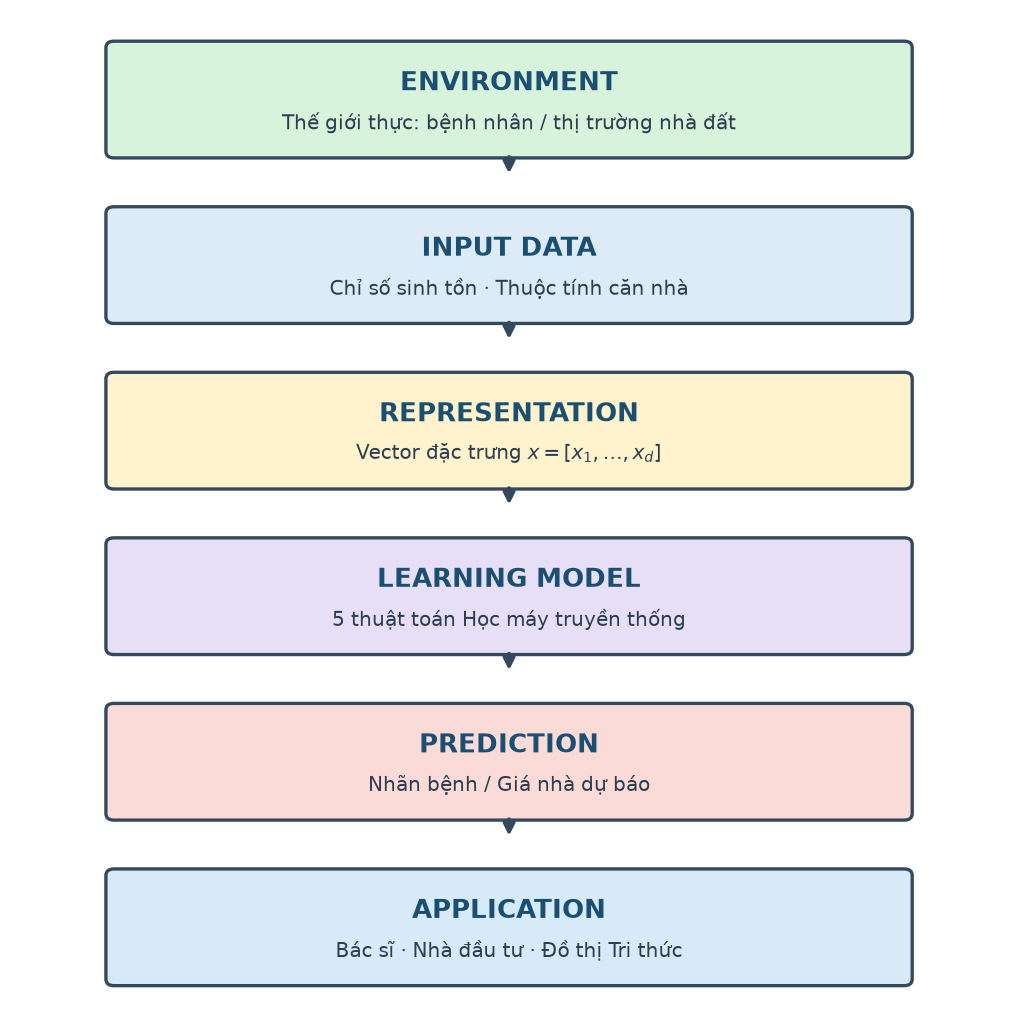

In [2]:
viz.plot_system_diagram()
show("fig_system_diagram", width=560)

---

## 3. Nguồn dữ liệu

**Pima Indians Diabetes Database** — dữ liệu lâm sàng thật, thu thập bởi
*National Institute of Diabetes and Digestive and Kidney Diseases* (Hoa Kỳ),
phân phối công khai qua UCI Machine Learning Repository và Kaggle.

- **Đối tượng:** phụ nữ gốc Pima, từ 21 tuổi trở lên, sinh sống tại bang Arizona.
- **Quy mô:** 768 bệnh nhân × 8 chỉ số + 1 nhãn.
- **Nhãn `Outcome`:** 1 nếu bệnh nhân được chẩn đoán mắc tiểu đường trong vòng
  5 năm sau lần đo, 0 nếu không.
- **Tệp trong dự án:** `data/raw/diabetes.csv`.

Đây là dữ liệu thật đo trên người thật, đáp ứng yêu cầu R1 của đề bài — không
phải dữ liệu sinh tự động hay dữ liệu đồ chơi.

In [3]:
raw = prep.load_diabetes_raw()

print(f"Tệp nguồn : {cfg.DIABETES_CSV.relative_to(ROOT)}")
print(f"Kích thước: {raw.shape[0]} quan sát × {raw.shape[1] - 1} đặc trưng + 1 nhãn")
raw.head()

Tệp nguồn : data\raw\diabetes.csv
Kích thước: 768 quan sát × 8 đặc trưng + 1 nhãn


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---

## 4. Mô tả dữ liệu

Tám đặc trưng gốc, toàn bộ là biến định lượng:

| Cột | Ý nghĩa | Đơn vị |
|---|---|---|
| `Pregnancies` | Số lần mang thai | lần |
| `Glucose` | Nồng độ glucose huyết tương sau 2 giờ nghiệm pháp dung nạp | mg/dL |
| `BloodPressure` | Huyết áp tâm trương | mm Hg |
| `SkinThickness` | Độ dày nếp gấp da vùng cơ tam đầu | mm |
| `Insulin` | Insulin huyết thanh sau 2 giờ | µU/mL |
| `BMI` | Chỉ số khối cơ thể | kg/m² |
| `DiabetesPedigreeFunction` | Hàm phả hệ — mức độ tiền sử gia đình mắc bệnh | — |
| `Age` | Tuổi | năm |

In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


Bảng thống kê mô tả trên đây bộc lộ ngay một vấn đề: giá trị **nhỏ nhất bằng 0**
xuất hiện ở `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` và `BMI`.
Không người sống nào có huyết áp bằng 0 hay BMI bằng 0 — đây là **quy ước mã hoá
cho dữ liệu thiếu**, không phải số đo thật. Mục 5 xử lý điều này.

In [6]:
zero_counts = pd.DataFrame(
    {
        "Số quan sát bằng 0": [(raw[c] == 0).sum() for c in cfg.DIABETES_ZERO_AS_MISSING],
        "Tỷ lệ (%)": [
            round((raw[c] == 0).mean() * 100, 2) for c in cfg.DIABETES_ZERO_AS_MISSING
        ],
    },
    index=cfg.DIABETES_ZERO_AS_MISSING,
)
zero_counts

,Số quan sát bằng 0,Tỷ lệ (%)
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


---

## 5. Biểu diễn dữ liệu

Đây là bước chuyển hoá **thế giới thực → biểu diễn tính toán**: mỗi bệnh nhân
trở thành một vector $x \in \mathbb{R}^d$. Biểu diễn được xây theo ba thao tác.

**(a) Đánh dấu giá trị 0 phi lý thành khuyết.** Giữ nguyên số 0 sẽ dạy mô hình
rằng tồn tại bệnh nhân có huyết áp bằng 0 — một quan hệ sai hoàn toàn về mặt y
sinh, và nó kéo lệch cả giá trị trung bình lẫn phương sai của cột.

**(b) Thiết kế đặc trưng phái sinh** (feature engineering). Bốn đặc trưng dưới
đây **không** có trong dữ liệu gốc; chúng mã hoá tri thức y khoa mà thuật toán
không tự suy ra được:

| Đặc trưng | Công thức | Tri thức miền được mã hoá |
|---|---|---|
| `Glucose_BMI_Risk` | `Glucose × BMI` | Rối loạn đường huyết và béo phì cộng hưởng phi tuyến; mô hình tuyến tính không tự tạo được số hạng tương tác. |
| `Glucose_Level` | Rời rạc hoá theo ngưỡng 99 / 125 | Ngưỡng chẩn đoán tiền đái tháo đường của Hiệp hội Đái tháo đường Hoa Kỳ. |
| `BMI_Class` | Rời rạc hoá theo 18.5 / 24.9 / 29.9 | Phân loại thể trạng theo chuẩn WHO. |
| `Age_Group` | Rời rạc hoá theo 30 / 45 / 60 | Nguy cơ tăng theo tuổi nhưng không tuyến tính. |

**(c) Chuẩn hoá** về trung bình 0, độ lệch chuẩn 1. Bắt buộc với mô hình dựa
trên khoảng cách hoặc gradient: không chuẩn hoá thì `Insulin` (thang hàng trăm)
sẽ lấn át hoàn toàn `DiabetesPedigreeFunction` (thang phần chục).

> **Điểm mấu chốt — điền khuyết phải nằm *trong* pipeline.** Bước (a) chỉ *đánh
> dấu* khuyết chứ không điền. Việc điền được giao cho `Pipeline` để giá trị
> trung vị chỉ học từ tập huấn luyện. Mục 21 phân tích hậu quả định lượng khi
> làm sai điều này.

Số giá trị khuyết sau khi đánh dấu 0 phi lý:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11


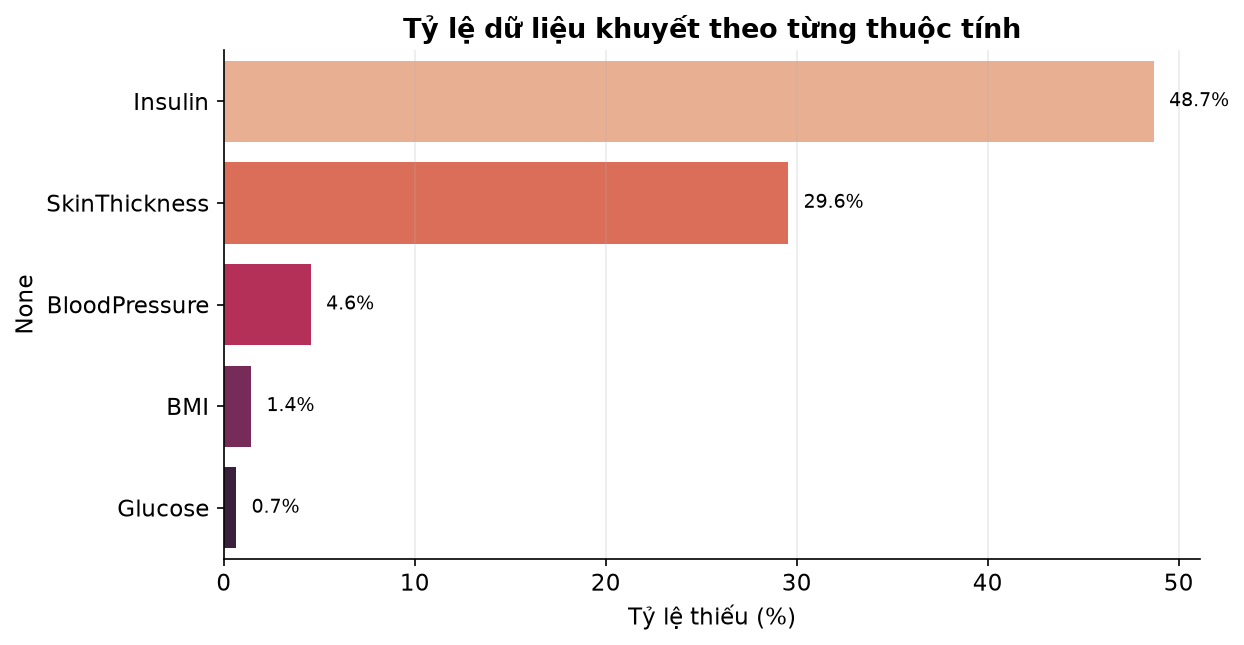

In [7]:
cleaned = prep.clean_diabetes(raw)

print("Số giá trị khuyết sau khi đánh dấu 0 phi lý:")
print(cleaned.isna().sum()[lambda s: s > 0].to_string())

viz.plot_missing_bar(cleaned[cfg.DIABETES_ZERO_AS_MISSING], "dia_missing_ratio")
show("dia_missing_ratio", width=640)

`Insulin` khuyết 374/768 và `SkinThickness` khuyết 227/768 — gần một nửa dữ
liệu. Con số này chính là lý do bước điền khuyết trở nên nhạy cảm tới mức có thể
làm hỏng toàn bộ kết quả (Mục 21).

Dưới đây là bản dữ liệu dùng riêng cho **biểu đồ khám phá**: đã điền khuyết bằng
trung vị toàn tập và đã thêm bốn đặc trưng thiết kế. Bản này không huấn luyện mô
hình nào nên không có khái niệm rò rỉ dữ liệu.

In [8]:
eda = prep.diabetes_eda_frame()

engineered_cols = ["Glucose_BMI_Risk", "Glucose_Level", "BMI_Class", "Age_Group"]
print(f"Biểu diễn cuối cùng: {eda.shape[1] - 1} chiều "
      f"({raw.shape[1] - 1} đặc trưng gốc + {len(engineered_cols)} đặc trưng thiết kế)")
eda[["Glucose", "BMI", "Age"] + engineered_cols].head()

Biểu diễn cuối cùng: 12 chiều (8 đặc trưng gốc + 4 đặc trưng thiết kế)


,Glucose,BMI,Age,Glucose_BMI_Risk,Glucose_Level,BMI_Class,Age_Group
0,148.0,33.6,50,4972.8,2,3,2
1,85.0,26.6,31,2261.0,0,2,1
2,183.0,23.3,32,4263.9,2,1,1
3,89.0,28.1,21,2500.9,0,2,0
4,137.0,43.1,33,5904.7,2,3,1


---

## 6. Phân tích đặc trưng và mục tiêu

Trước hết là **phân bố nhãn**. Dữ liệu mất cân bằng theo tỷ lệ khoảng 65/35, đủ
để một mô hình luôn đoán "khoẻ mạnh" đạt Accuracy 65% mà không phát hiện được
một ca bệnh nào — lý do Accuracy bị loại khỏi vai trò độ đo chính.

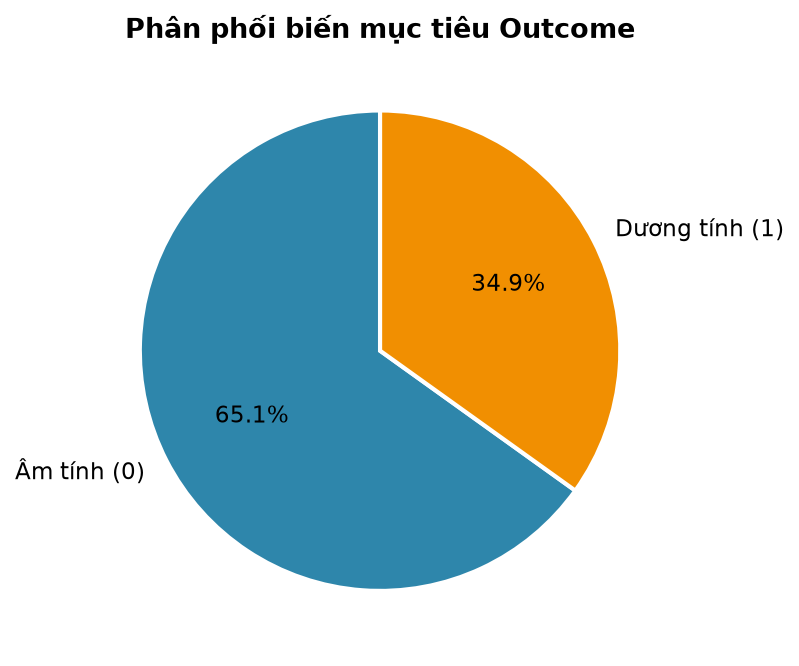

Âm tính   (0): 500 quan sát (65.10%)
Dương tính (1): 268 quan sát (34.90%)


In [9]:
viz.plot_target_pie(
    raw[cfg.DIABETES_TARGET], "dia_pie_outcome",
    labels=["Âm tính (0)", "Dương tính (1)"],
)
show("dia_pie_outcome", width=460)

balance = raw[cfg.DIABETES_TARGET].value_counts().sort_index()
print(f"Âm tính   (0): {balance[0]:>3} quan sát ({balance[0] / len(raw):.2%})")
print(f"Dương tính (1): {balance[1]:>3} quan sát ({balance[1] / len(raw):.2%})")

Tiếp theo là **tương quan tuyến tính giữa từng đặc trưng và nhãn**. Đây là phép
sàng lọc thô: hệ số cao báo hiệu đặc trưng hữu ích, nhưng hệ số thấp **không**
đồng nghĩa vô dụng, vì Pearson chỉ thấy quan hệ tuyến tính.

In [10]:
corr_target = (
    eda.drop(columns=[cfg.DIABETES_TARGET])
       .corrwith(eda[cfg.DIABETES_TARGET])
       .sort_values(key=abs, ascending=False)
       .rename("Tương quan với Outcome")
       .to_frame()
       .round(4)
)
corr_target

,Tương quan với Outcome
Glucose_BMI_Risk,0.5199
Glucose,0.4928
Glucose_Level,0.4356
BMI,0.3120
BMI_Class,0.3098
Age,0.2384
Age_Group,0.2322
Pregnancies,0.2219
SkinThickness,0.2149
Insulin,0.2038


`Glucose` dẫn đầu — hoàn toàn nhất quán với y văn: nồng độ glucose huyết tương
là chỉ dấu trực tiếp nhất của rối loạn dung nạp đường. Đáng chú ý, các đặc trưng
thiết kế `Glucose_Level` và `Glucose_BMI_Risk` cũng nằm nhóm đầu, cho thấy việc
mã hoá tri thức miền đã tạo ra tín hiệu thật chứ không chỉ nhân bản cột gốc.

---

## 7. Phân tích khám phá (EDA)

Bốn nhóm biểu đồ, mỗi nhóm trả lời một câu hỏi khác nhau về dữ liệu.

### 7.1 Phân bố đơn biến — dữ liệu có dạng gì?

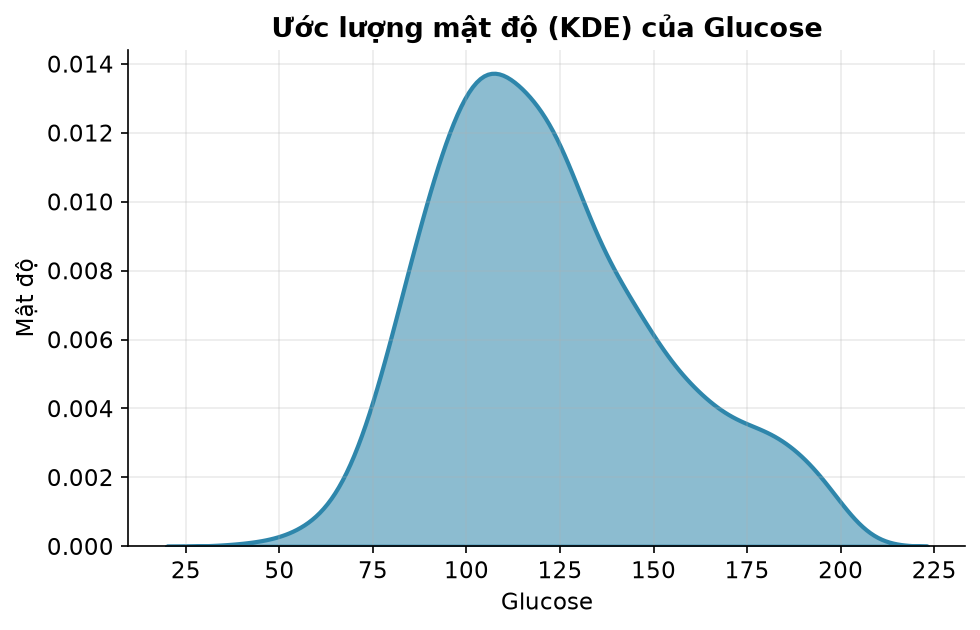

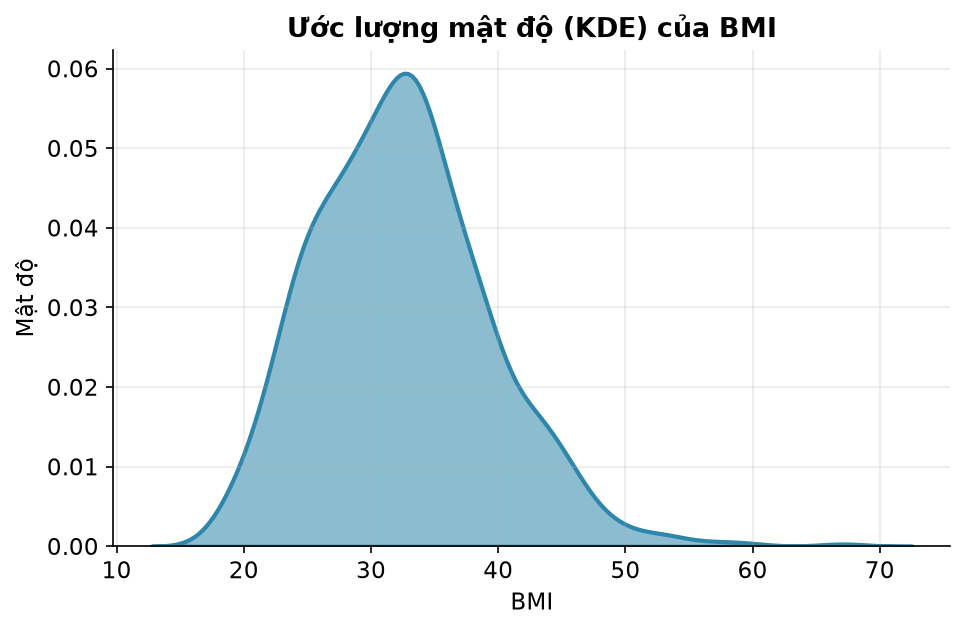

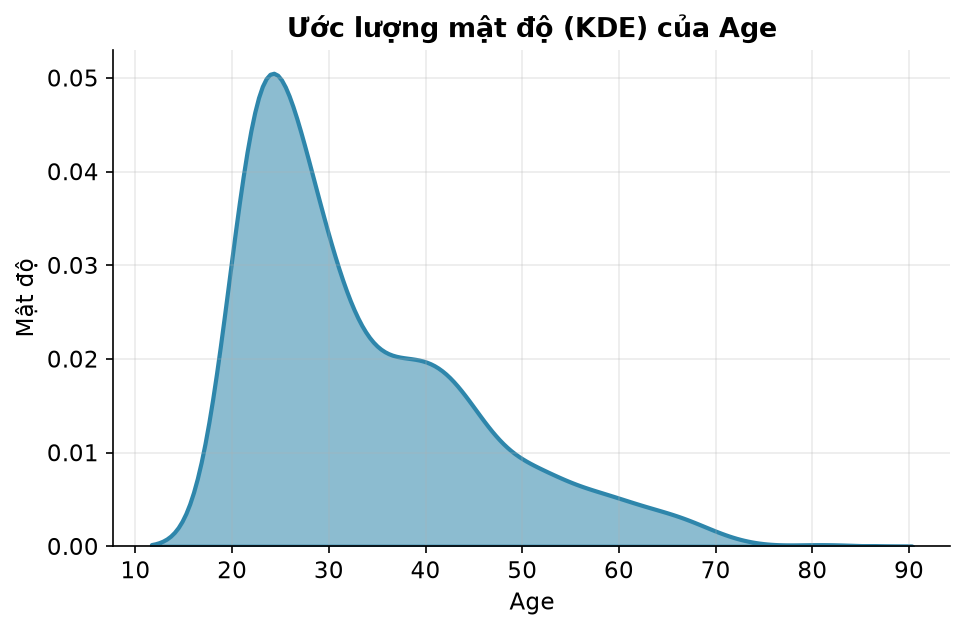

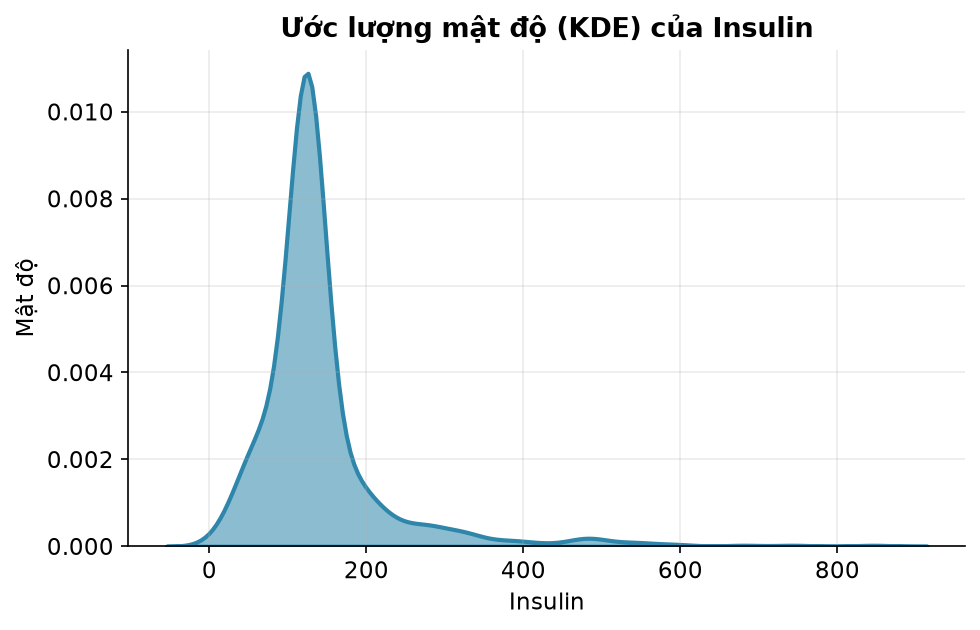

In [11]:
for col in ["Glucose", "BMI", "Age", "Insulin"]:
    viz.plot_kde(eda, col, f"dia_kde_{col.lower()}")

for col in ["Glucose", "BMI", "Age", "Insulin"]:
    show(f"dia_kde_{col.lower()}", width=560)

`Glucose` và `BMI` xấp xỉ phân bố chuẩn; `Age` và `Insulin` lệch phải rõ rệt —
phần lớn bệnh nhân trẻ, một đuôi dài người lớn tuổi. Độ lệch này là lý do các mô
hình dựa trên cây (Decision Tree, Random Forest, XGBoost) thường tỏ ra bền hơn
mô hình tuyến tính trên dữ liệu y sinh.

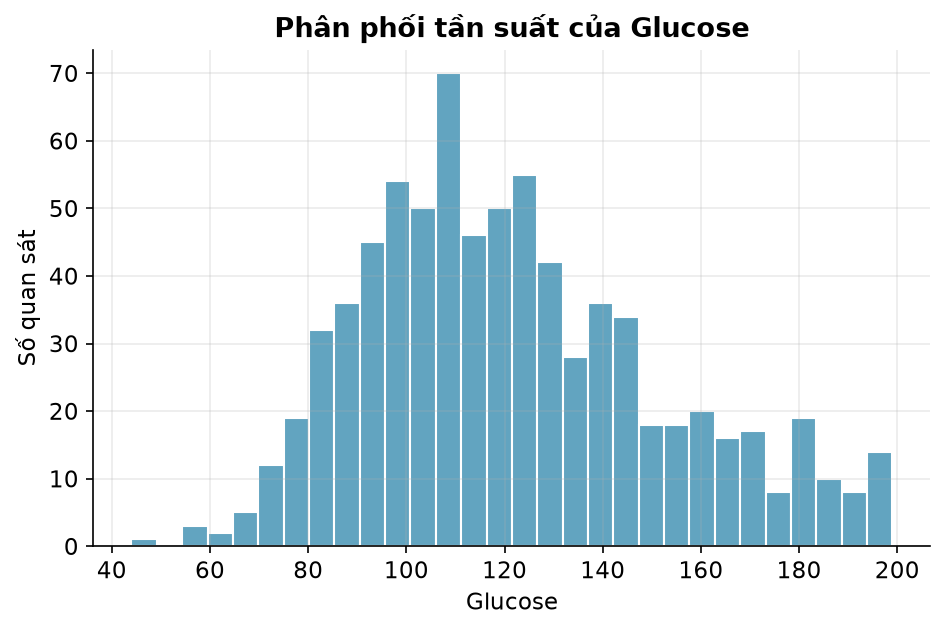

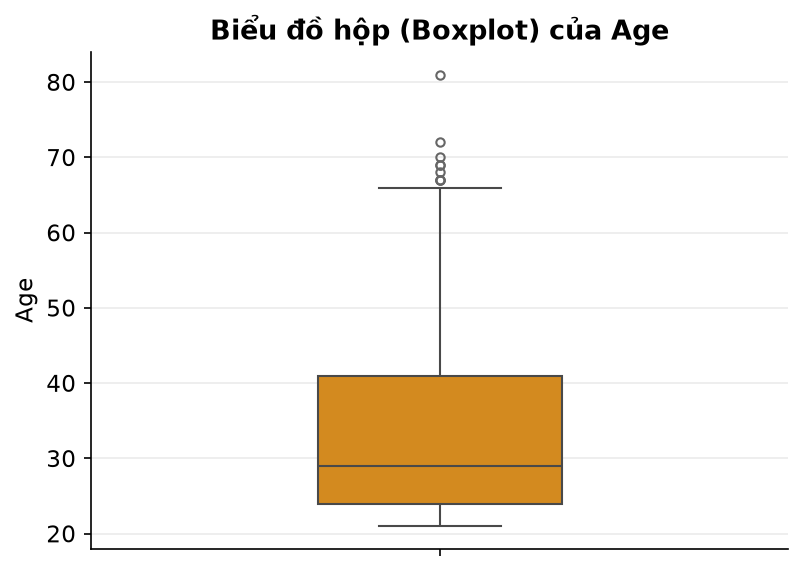

In [12]:
viz.plot_histogram(eda, "Glucose", "dia_hist_glucose")
show("dia_hist_glucose", width=560)

viz.plot_boxplot(eda, "Age", "dia_box_age")
show("dia_box_age", width=560)

### 7.2 Giá trị ngoại lai — dữ liệu có bất thường không?

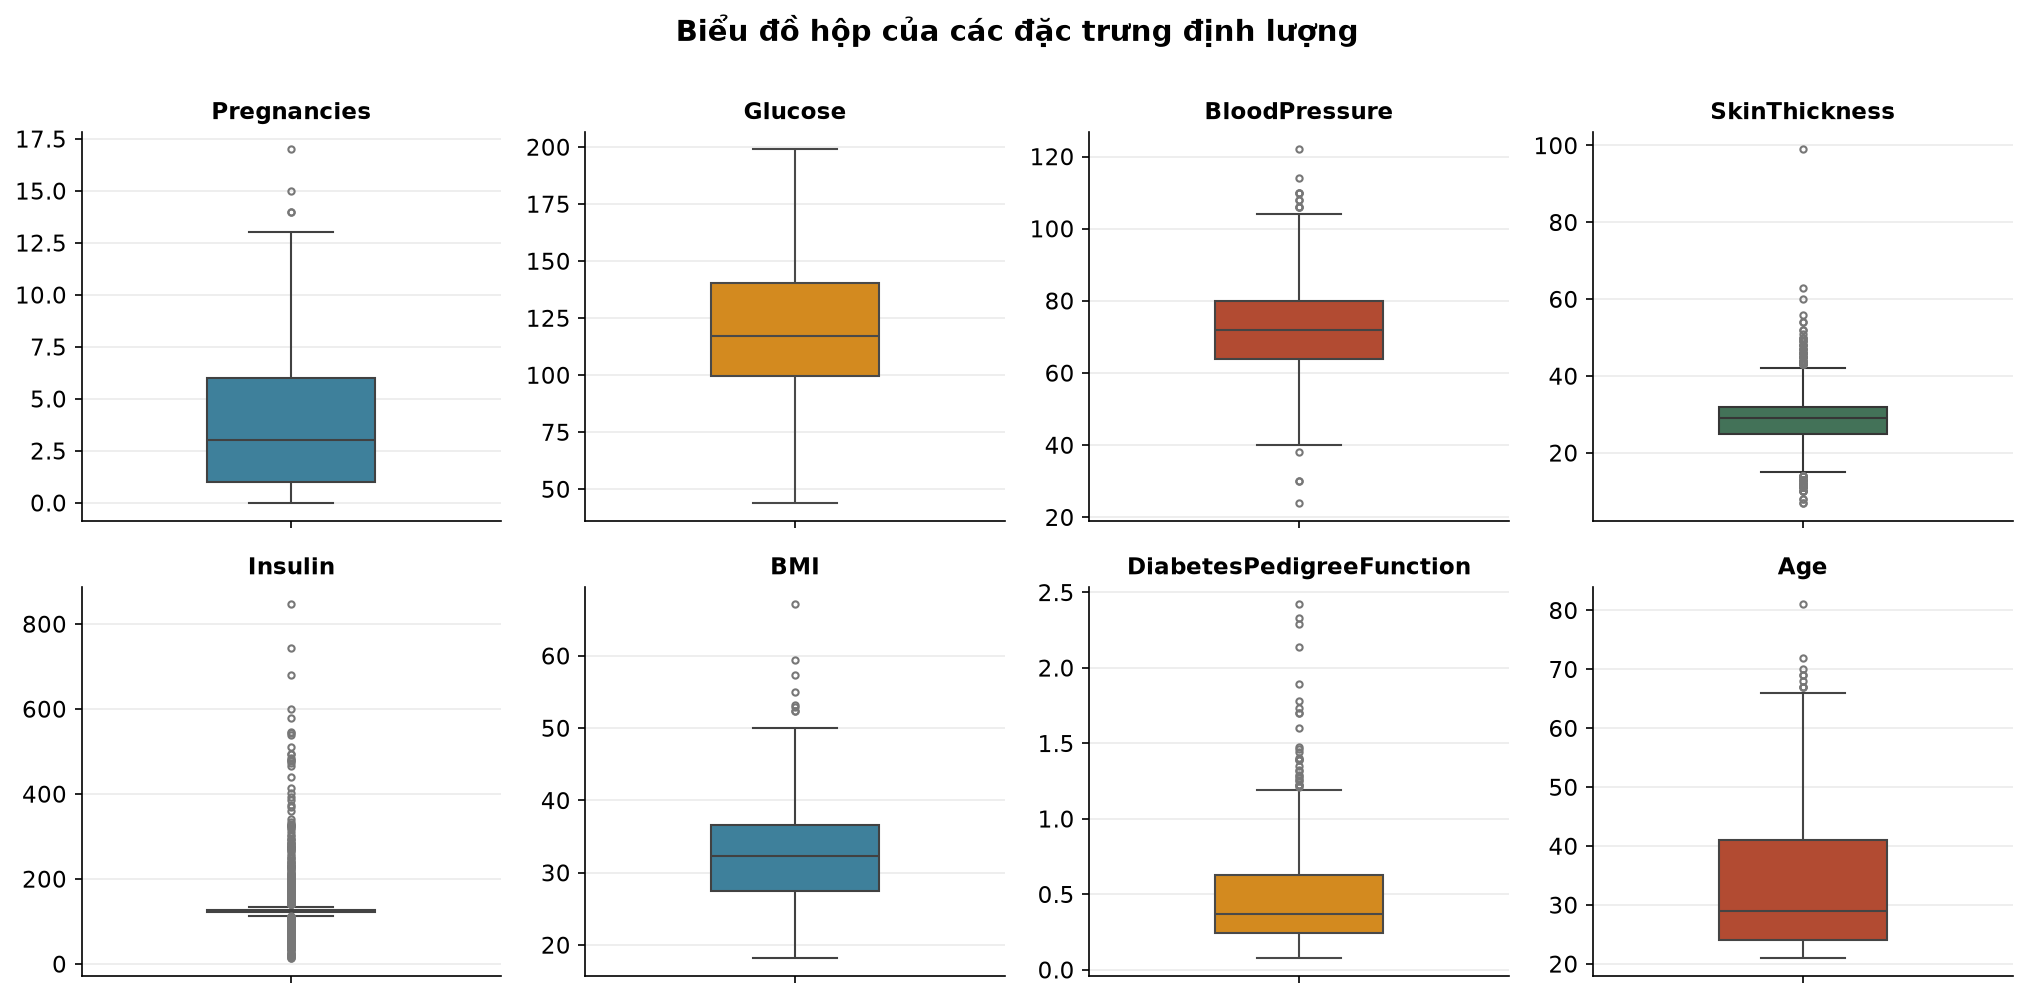

In [13]:
viz.plot_boxplot_grid(
    eda,
    ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
     "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"],
    "dia_box_grid",
)
show("dia_box_grid", width=860)

`Insulin` có nhiều điểm ngoại lai nhất. Chúng **không** bị loại bỏ: trong y sinh,
giá trị cực đoan thường là ca bệnh nặng thật — chính là nhóm mà hệ thống sàng
lọc cần phát hiện nhất. Loại chúng đi là tự tay xoá đi tín hiệu quan trọng nhất.

### 7.3 Phân bố theo lớp — đặc trưng nào tách được hai nhóm?

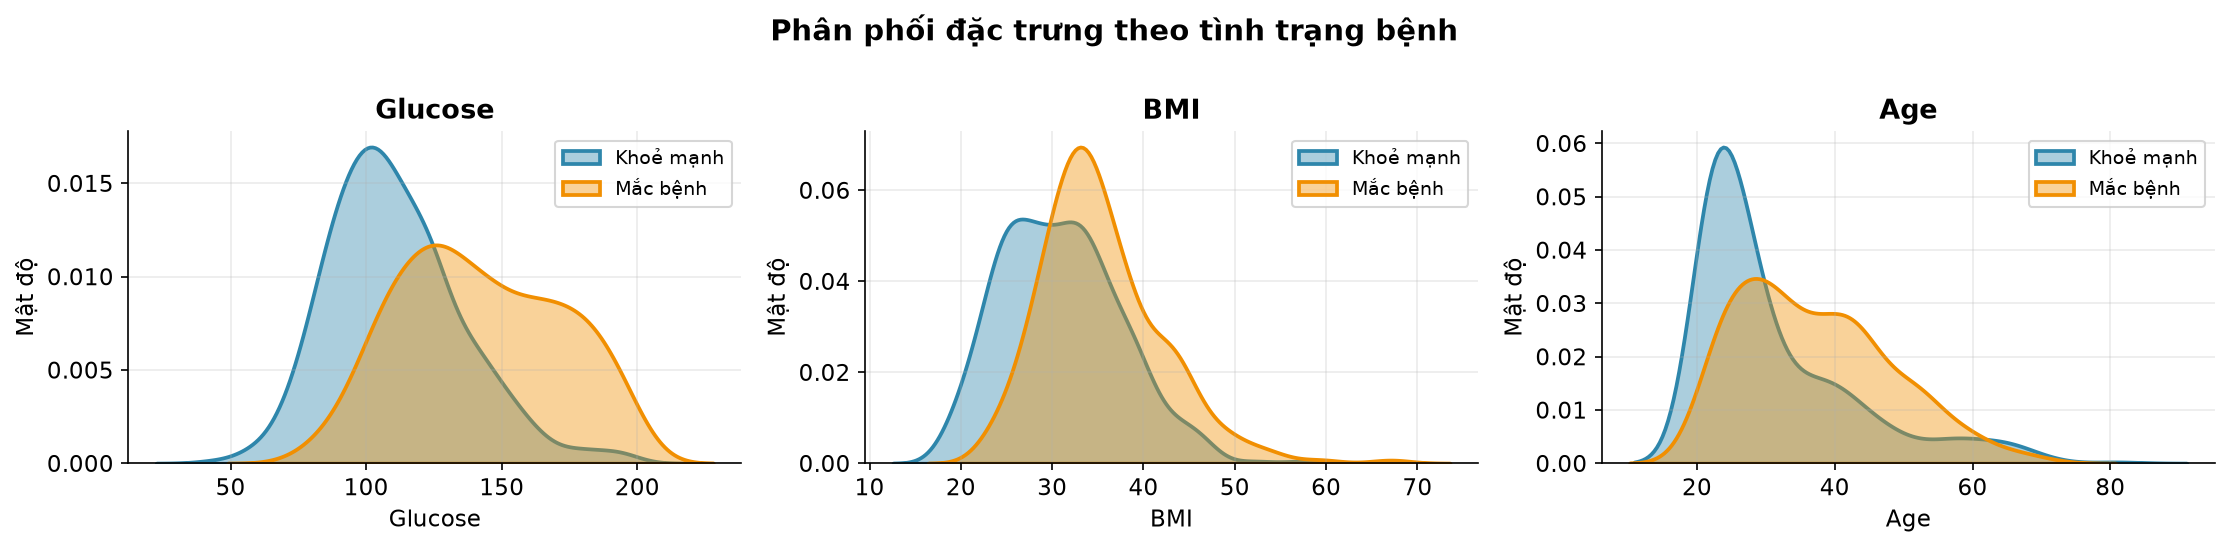

In [14]:
viz.plot_kde_by_class(
    eda, ["Glucose", "BMI", "Age"], cfg.DIABETES_TARGET,
    "dia_kde_by_class", labels=["Khoẻ mạnh", "Mắc bệnh"],
)
show("dia_kde_by_class", width=860)

`Glucose` cho hai đỉnh tách nhau rõ nhất — đây là đặc trưng mang nhiều thông tin
phân biệt nhất. `BMI` và `Age` chồng lấn nhiều hơn: chúng dịch chuyển phân bố
nhưng không tách hẳn, nên chỉ hữu ích khi kết hợp với đặc trưng khác. Quan sát
này giải thích vì sao đặc trưng tương tác `Glucose × BMI` lại có giá trị.

### 7.4 Tương quan giữa các đặc trưng — có dư thừa thông tin không?

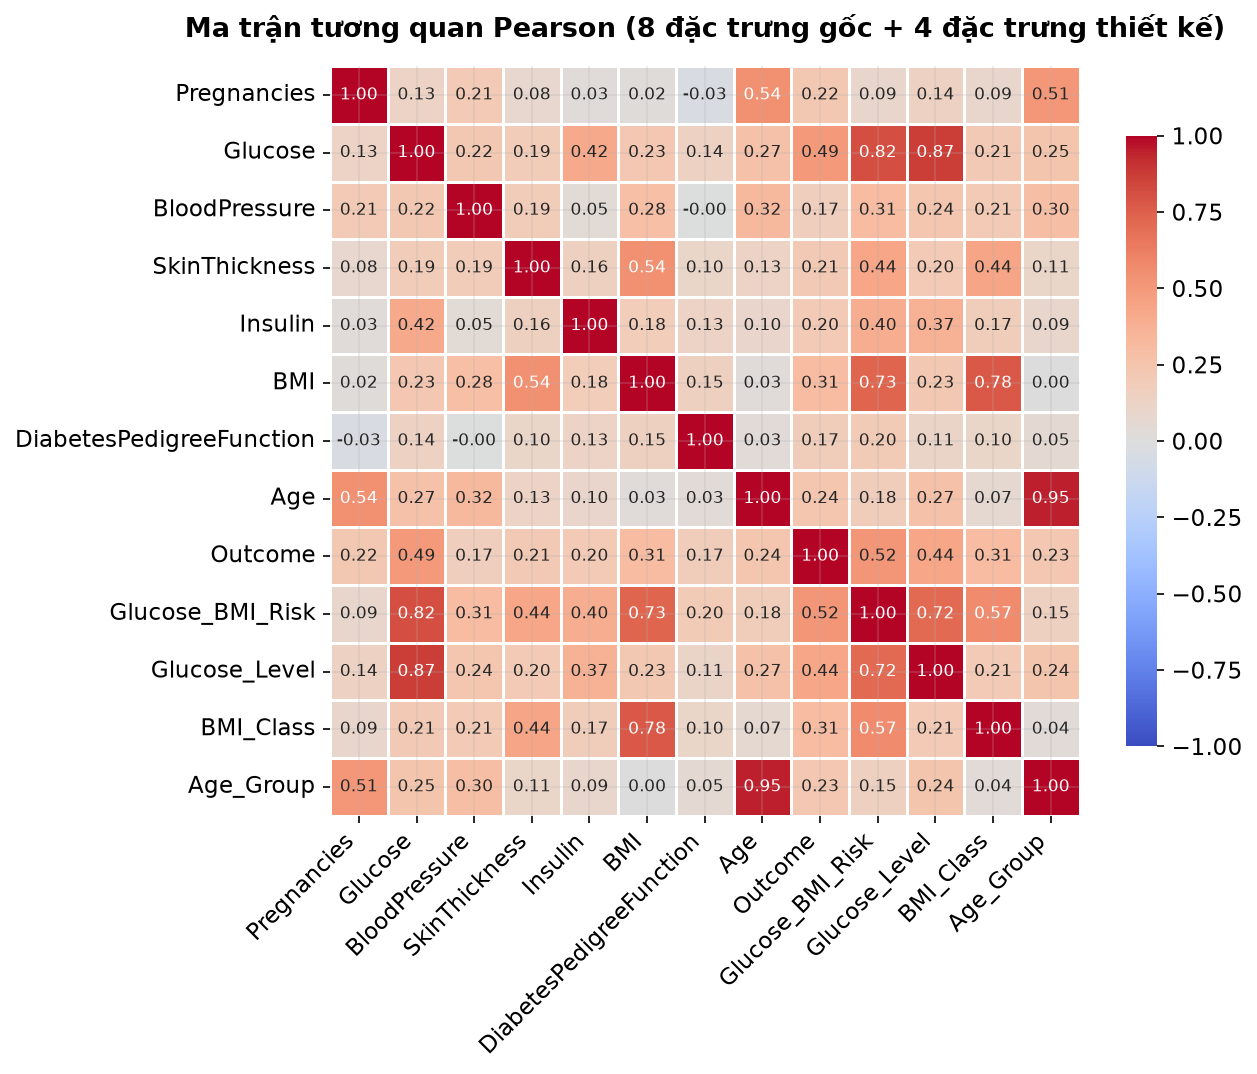

In [15]:
viz.plot_correlation_heatmap(
    eda, "dia_corr_heatmap",
    "Ma trận tương quan Pearson (8 đặc trưng gốc + 4 đặc trưng thiết kế)",
)
show("dia_corr_heatmap", width=760)

Các đặc trưng gốc tương quan với nhau ở mức thấp tới trung bình, nên không cần
loại cột nào vì đa cộng tuyến. Cặp tương quan cao duy nhất nằm giữa đặc trưng
thiết kế và đặc trưng gốc sinh ra nó (`Glucose_Level` với `Glucose`) — điều này
là hiển nhiên theo cách xây dựng và không gây hại cho mô hình dựa trên cây.

---

## 8. Chia tập huấn luyện / kiểm tra / ngoại kiểm

Dữ liệu được chia **ba** phần chứ không phải hai:

| Tập | Tỷ lệ | Vai trò |
|---|---|---|
| Huấn luyện (train) | 72% | Học tham số mô hình |
| Kiểm tra (test) | 18% | So sánh mô hình, chọn siêu tham số |
| Ngoại kiểm (out-of-distribution) | 10% | Đo tổng quát hoá thật sự |

Tập **ngoại kiểm** được cắt ra **trước tiên** và không tham gia bất kỳ bước nào
của quá trình phát triển. Lý do: sau nhiều vòng thử nghiệm, tập kiểm tra thông
thường đã gián tiếp ảnh hưởng tới lựa chọn mô hình, nên điểm số trên nó là ước
lượng lạc quan. Tập ngoại kiểm đóng vai trò dữ liệu "thế giới thực" chưa ai chạm
vào (Mục 15 dùng nó để kiểm chứng).

Việc chia dùng **phân tầng theo nhãn** (`stratify=True`) để tỷ lệ 65/35 được giữ
nguyên trong cả ba tập — không thì tập kiểm tra 139 quan sát có thể lệch tỷ lệ
đáng kể chỉ do ngẫu nhiên.

Lưu ý `X` trả về ở đây **vẫn còn giá trị khuyết**: bước điền khuyết cố tình để
lại cho `Pipeline` ở Mục 9 trở đi.

In [16]:
X, y = prep.prepare_diabetes(clean=True)
X_train, X_test, X_ood, y_train, y_test, y_ood = tr.three_way_split(X, y, stratify=True)

split_table = pd.DataFrame(
    {
        "Số quan sát": [len(X_train), len(X_test), len(X_ood)],
        "Tỷ lệ dương tính": [y_train.mean(), y_test.mean(), y_ood.mean()],
    },
    index=["Huấn luyện", "Kiểm tra", "Ngoại kiểm"],
).round(4)

print(f"Ma trận đặc trưng đầu vào: {X.shape[1]} cột "
      f"(4 đặc trưng thiết kế được thêm bên trong pipeline)")
print(f"Số giá trị khuyết còn lại trong X: {int(X.isna().sum().sum())}")
split_table

Ma trận đặc trưng đầu vào: 8 cột (4 đặc trưng thiết kế được thêm bên trong pipeline)
Số giá trị khuyết còn lại trong X: 652


,Số quan sát,Tỷ lệ dương tính
Huấn luyện,552,0.3496
Kiểm tra,139,0.3453
Ngoại kiểm,77,0.3506


---

## 9. Mô hình cơ sở (Baseline)

Mô hình cơ sở luôn đoán **lớp chiếm đa số** (`DummyClassifier`), tức luôn trả
lời "khoẻ mạnh". Nó không học gì cả, và tồn tại để trả lời một câu hỏi bắt buộc:
*mô hình học được có thật sự mang lại giá trị so với một quy tắc đoán mù?*
(yêu cầu R6).

Mô hình cơ sở này minh hoạ luôn cái bẫy của Accuracy: nó đạt khoảng 65% mà
Recall bằng **0** — bỏ sót toàn bộ người bệnh.

In [17]:
baseline = tr.make_pipeline(tr.diabetes_preprocessor(), tr.build_classifier_baseline())
baseline.fit(X_train, y_train)

base_metrics = ev.classification_metrics(y_test, baseline.predict(X_test))
pd.DataFrame([base_metrics], index=["Baseline (đoán lớp đa số)"]).round(4)

,Accuracy,Precision,Recall,F1-Score
Baseline (đoán lớp đa số),0.6547,0.0,0.0,0.0


---

## 10. Mô hình 1 — Logistic Regression

Đề bài yêu cầu tối thiểu 4 mô hình (R7); notebook này dùng **5**, mỗi mô hình
theo một nguyên lý học khác nhau. Cả năm được huấn luyện trong **một lần gọi**
`tr.fit_all` để bảo đảm dùng chung tuyệt đối một giao thức: cùng tập huấn luyện,
cùng bộ tiền xử lý, cùng hạt giống. Các mục 10–13 lần lượt trình bày từng mô
hình từ kết quả chung đó.

Mỗi mô hình được gói trong một `Pipeline` gồm bốn bước — *điền khuyết → thiết kế
đặc trưng → chuẩn hoá → thuật toán học*. Nhờ vậy phép biến đổi chỉ `fit` trên
tập huấn luyện rồi `transform` y nguyên cho tập kiểm tra, loại bỏ rò rỉ dữ liệu
(data leakage).

In [18]:
started = time.time()
fitted = tr.fit_all(tr.build_classifiers(), tr.diabetes_preprocessor, X_train, y_train)
print(f"Đã huấn luyện {len(fitted)} mô hình trong {time.time() - started:.1f}s")

for name, pipe in fitted.items():
    print(f"  · {name:<24} {type(pipe.named_steps['model']).__name__}")

Đã huấn luyện 5 mô hình trong 1.0s
  · Logistic Regression      LogisticRegression
  · K-Nearest Neighbors      KNeighborsClassifier
  · Decision Tree            DecisionTreeClassifier
  · Random Forest            RandomForestClassifier
  · XGBoost                  XGBClassifier


In [19]:
def report(name: str) -> pd.DataFrame:
    """Chấm điểm một mô hình đã huấn luyện trên tập kiểm tra."""
    pipe = fitted[name]
    proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None
    return pd.DataFrame(
        [ev.classification_metrics(y_test, pipe.predict(X_test), proba)], index=[name]
    ).round(4)


report("Logistic Regression")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.7914,0.7436,0.6042,0.6667,0.8709


**Nguyên lý.** Học một ranh giới **tuyến tính** trong không gian log-odds:

$$ \log \frac{P(y=1 \mid x)}{P(y=0 \mid x)} = w^{\top} x + b $$

**Vì sao chọn.** Đây là mô hình dễ diễn giải nhất trong danh mục — mỗi hệ số
$w_j$ cho biết một đơn vị độ lệch chuẩn của đặc trưng $j$ làm log-odds mắc bệnh
thay đổi bao nhiêu. Trong y tế, khả năng giải thích quyết định thường quan trọng
ngang với độ chính xác. Mô hình cũng nhạy với thang đo nên bắt buộc phải chuẩn
hoá — chính là bước `StandardScaler` trong pipeline.

In [20]:
logreg = fitted["Logistic Regression"]

# Tên đặc trưng lấy từ bước chuẩn hoá — đây là bước cuối của phần tiền xử lý nên
# nó thấy đúng 12 cột mà thuật toán học nhận vào (8 gốc + 4 thiết kế).
feature_names = logreg.named_steps["prep"].named_steps["scale"].feature_names_in_

coef = pd.Series(
    logreg.named_steps["model"].coef_[0], index=feature_names
).sort_values(key=abs, ascending=False)

coef.rename("Hệ số hồi quy").to_frame().round(4)

,Hệ số hồi quy
Glucose,0.7860
BMI_Class,0.4382
Glucose_BMI_Risk,0.3656
Pregnancies,0.3163
DiabetesPedigreeFunction,0.3050
BMI,0.1859
Age_Group,0.1220
SkinThickness,-0.1012
BloodPressure,-0.0670
Age,0.0571


---

## 11. Mô hình 2 — K-Nearest Neighbors

**Nguyên lý.** Không học tham số nào (lazy learning). Khi cần dự đoán, mô hình
tìm $k$ bệnh nhân gần nhất trong tập huấn luyện theo khoảng cách Euclid và lấy
nhãn theo đa số.

**Vì sao chọn.** KNN không giả định bất kỳ dạng hàm nào, nên nắm được ranh giới
phi tuyến mà Logistic Regression bỏ lỡ. Đổi lại nó **cực kỳ** nhạy với thang đo
(khoảng cách bị đặc trưng thang lớn chi phối) và với giá trị $k$ — Mục 16 khảo
sát $k$ như một thực nghiệm có kiểm soát.

In [21]:
report("K-Nearest Neighbors")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
K-Nearest Neighbors,0.7842,0.6957,0.6667,0.6809,0.8462


---

## 12. Mô hình 3 — Decision Tree

**Nguyên lý.** Chia đệ quy không gian đặc trưng bằng các ngưỡng trên từng trục,
chọn ngưỡng làm giảm mạnh nhất độ vẩn (impurity) của nút.

**Vì sao chọn.** Cây quyết định cho ra luật dạng *nếu — thì* đọc được trực tiếp,
và bất biến với phép đổi thang đo. Giới hạn `max_depth=6` là biện pháp chống học
thuộc: cây không giới hạn sẽ mọc tới lá chỉ chứa một bệnh nhân và ghi nhớ nhiễu.

Một hệ quả kỹ thuật của cây nông sẽ trở lại ở Mục 16: cây chỉ trả về **vài giá
trị xác suất rời rạc**, nên nó không phù hợp để khảo sát ngưỡng quyết định.

In [22]:
report("Decision Tree")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Decision Tree,0.7266,0.6786,0.3958,0.5,0.7446


---

## 13. Mô hình 4 và 5 — Random Forest, XGBoost

Hai mô hình tổ hợp (ensemble), khác nhau ở cách kết hợp cây.

**Random Forest — bagging.** Huấn luyện 300 cây độc lập trên các mẫu bootstrap
khác nhau rồi lấy trung bình. Mục tiêu là **giảm phương sai**: mỗi cây học thuộc
theo một kiểu riêng, trung bình lại thì phần nhiễu triệt tiêu nhau.

**XGBoost — boosting.** Cộng dồn **tuần tự** các cây yếu, mỗi cây mới học phần
sai số mà tổ hợp trước đó còn để lại. Mục tiêu là **giảm độ chệch**. Tốc độ học
0.05 giữ cho từng bước hiệu chỉnh đủ nhỏ để không vọt qua điểm tối ưu.

In [23]:
pd.concat([report("Random Forest"), report("XGBoost")])

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.7194,0.6154,0.5000,0.5517,0.8191
XGBoost,0.7194,0.5957,0.5833,0.5895,0.7905


---

## 14. Đánh giá

**Chọn độ đo cho đúng bài toán** là một quyết định khoa học, không phải thủ tục.
Với dữ liệu mất cân bằng 65/35 và bối cảnh sàng lọc y tế:

| Độ đo | Công thức | Vì sao cần |
|---|---|---|
| Accuracy | $\dfrac{TP + TN}{n}$ | Dễ hiểu, nhưng **gây hiểu nhầm** ở đây: mô hình cơ sở đạt 65% mà không phát hiện ca bệnh nào. |
| Precision | $\dfrac{TP}{TP + FP}$ | Trong số ca bị cảnh báo, bao nhiêu là bệnh thật — chi phối chi phí xét nghiệm thừa. |
| **Recall** | $\dfrac{TP}{TP + FN}$ | Trong số ca bệnh thật, bắt được bao nhiêu. **Đây là độ đo quan trọng nhất về mặt lâm sàng**: mỗi FN là một bệnh nhân bị bỏ sót. |
| **F1-Score** | $2 \cdot \dfrac{P \cdot R}{P + R}$ | Trung bình điều hoà, phạt nặng mô hình lệch hẳn về một phía. Dùng làm tiêu chí xếp hạng chính. |
| ROC-AUC | Diện tích dưới đường ROC | Đo khả năng **xếp hạng** rủi ro, độc lập với ngưỡng quyết định. |

Toàn bộ mô hình được chấm dưới **cùng một giao thức**: cùng tập kiểm tra, cùng
hạt giống, cùng bộ độ đo. Chỉ khi giao thức đồng nhất thì phép so sánh mới có ý
nghĩa khoa học.

In [24]:
results = ev.compare_classifiers(fitted, X_test, y_test)
results_with_base = pd.concat(
    [pd.DataFrame([{"Model": "Baseline (Dummy)", **base_metrics}]), results],
    ignore_index=True,
)
results_with_base.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline (Dummy),0.6547,0.0000,0.0000,0.0000,NaN
1,K-Nearest Neighbors,0.7842,0.6957,0.6667,0.6809,0.8462
2,Logistic Regression,0.7914,0.7436,0.6042,0.6667,0.8709
3,XGBoost,0.7194,0.5957,0.5833,0.5895,0.7905
4,Random Forest,0.7194,0.6154,0.5000,0.5517,0.8191
5,Decision Tree,0.7266,0.6786,0.3958,0.5000,0.7446


**Ma trận nhầm lẫn** cho thấy sai lầm rơi vào đâu, điều mà một con số tổng hợp
không nói được. Hai ô đáng quan tâm là FN (bệnh nhân mắc bệnh bị cho là khoẻ) và
FP (người khoẻ bị cảnh báo nhầm).

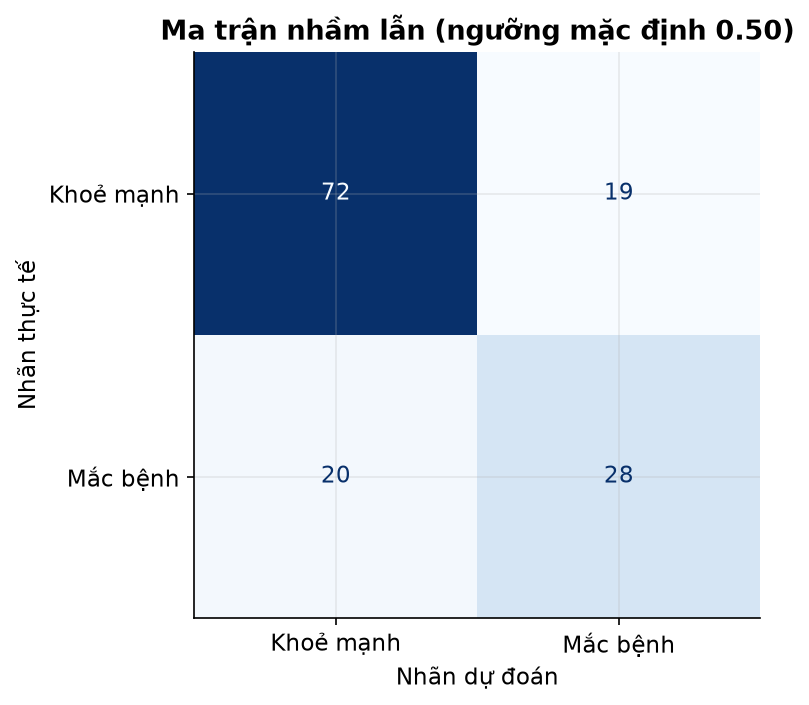

In [25]:
viz.plot_confusion_matrix(
    fitted["XGBoost"], X_test, y_test, "dia_confusion_default",
    labels=["Khoẻ mạnh", "Mắc bệnh"],
)
show("dia_confusion_default", width=520)

**Đường cong ROC** trả lời một câu hỏi khác hẳn bảng độ đo ở trên.
Bảng chấm điểm mô hình tại **một** ngưỡng cố định 0,50; ROC quét ngưỡng
từ 1 về 0 và vẽ Recall theo tỷ lệ Dương tính giả, nên nó đo **khả năng
xếp hạng** — mô hình có xếp người bệnh lên trên người khoẻ hay không,
bất kể ta cắt ở đâu.

Hệ quả thực dụng: ROC-AUC là độ đo duy nhất trong nhóm **không đổi** khi
Thực nghiệm 2 hạ ngưỡng xuống 0,15. Nếu hạ ngưỡng làm F1 tăng mà AUC giữ
nguyên thì cái được cải thiện là *điểm cắt*, không phải *mô hình*.

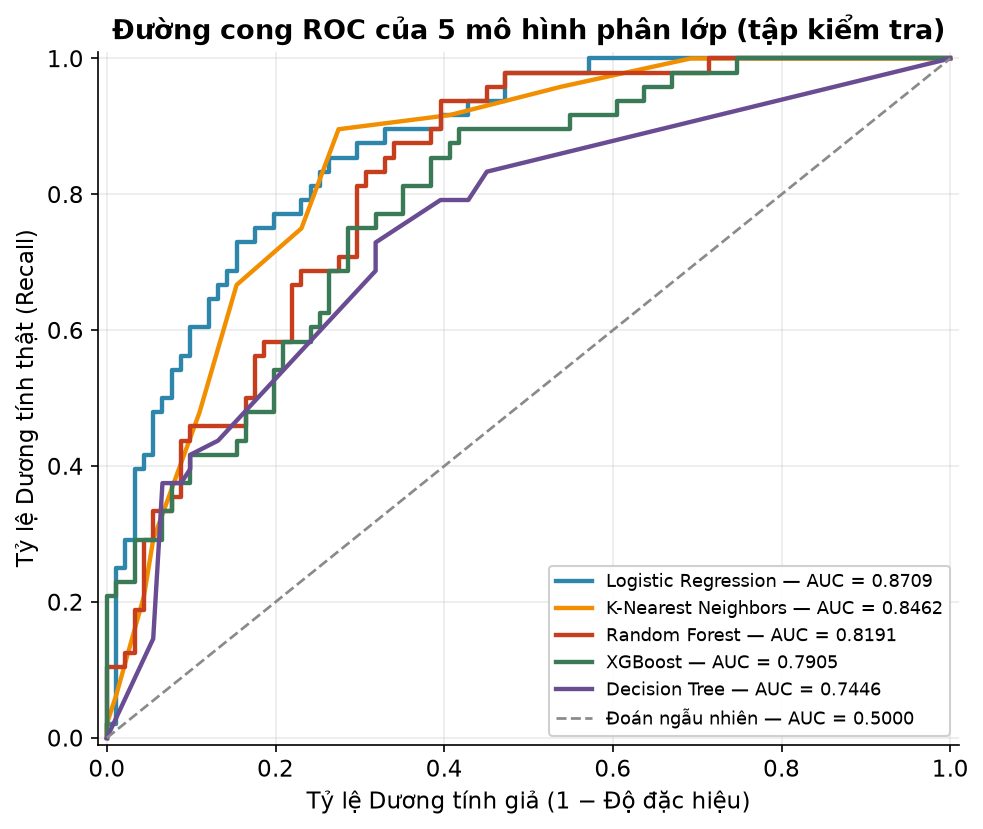

In [26]:
viz.plot_roc_curves(fitted, X_test, y_test, "dia_roc_curves",
                    "Đường cong ROC của 5 mô hình phân lớp (tập kiểm tra)")
show("dia_roc_curves", width=620)

Thứ tự trên đường cong ROC **không** trùng thứ tự trên bảng F1. Logistic
Regression dẫn đầu về AUC nhưng chỉ đứng thứ hai về F1, còn K-Nearest
Neighbors thì ngược lại. Đó không phải mâu thuẫn: AUC nói mô hình xếp hạng
tốt, F1 nói ngưỡng 0,50 có phải điểm cắt tốt cho mô hình ấy hay không. Một
mô hình xếp hạng giỏi mà bị cắt sai chỗ vẫn cho F1 thấp — và đó chính là
khe hở mà Thực nghiệm 2 khai thác.

**Lưới ma trận nhầm lẫn** dưới đây bổ sung nốt góc nhìn còn thiếu: không
phải *sai bao nhiêu* mà là *sai theo kiểu gì*. Mọi ô dùng chung một thang
màu nên so sánh được trực tiếp bằng mắt.

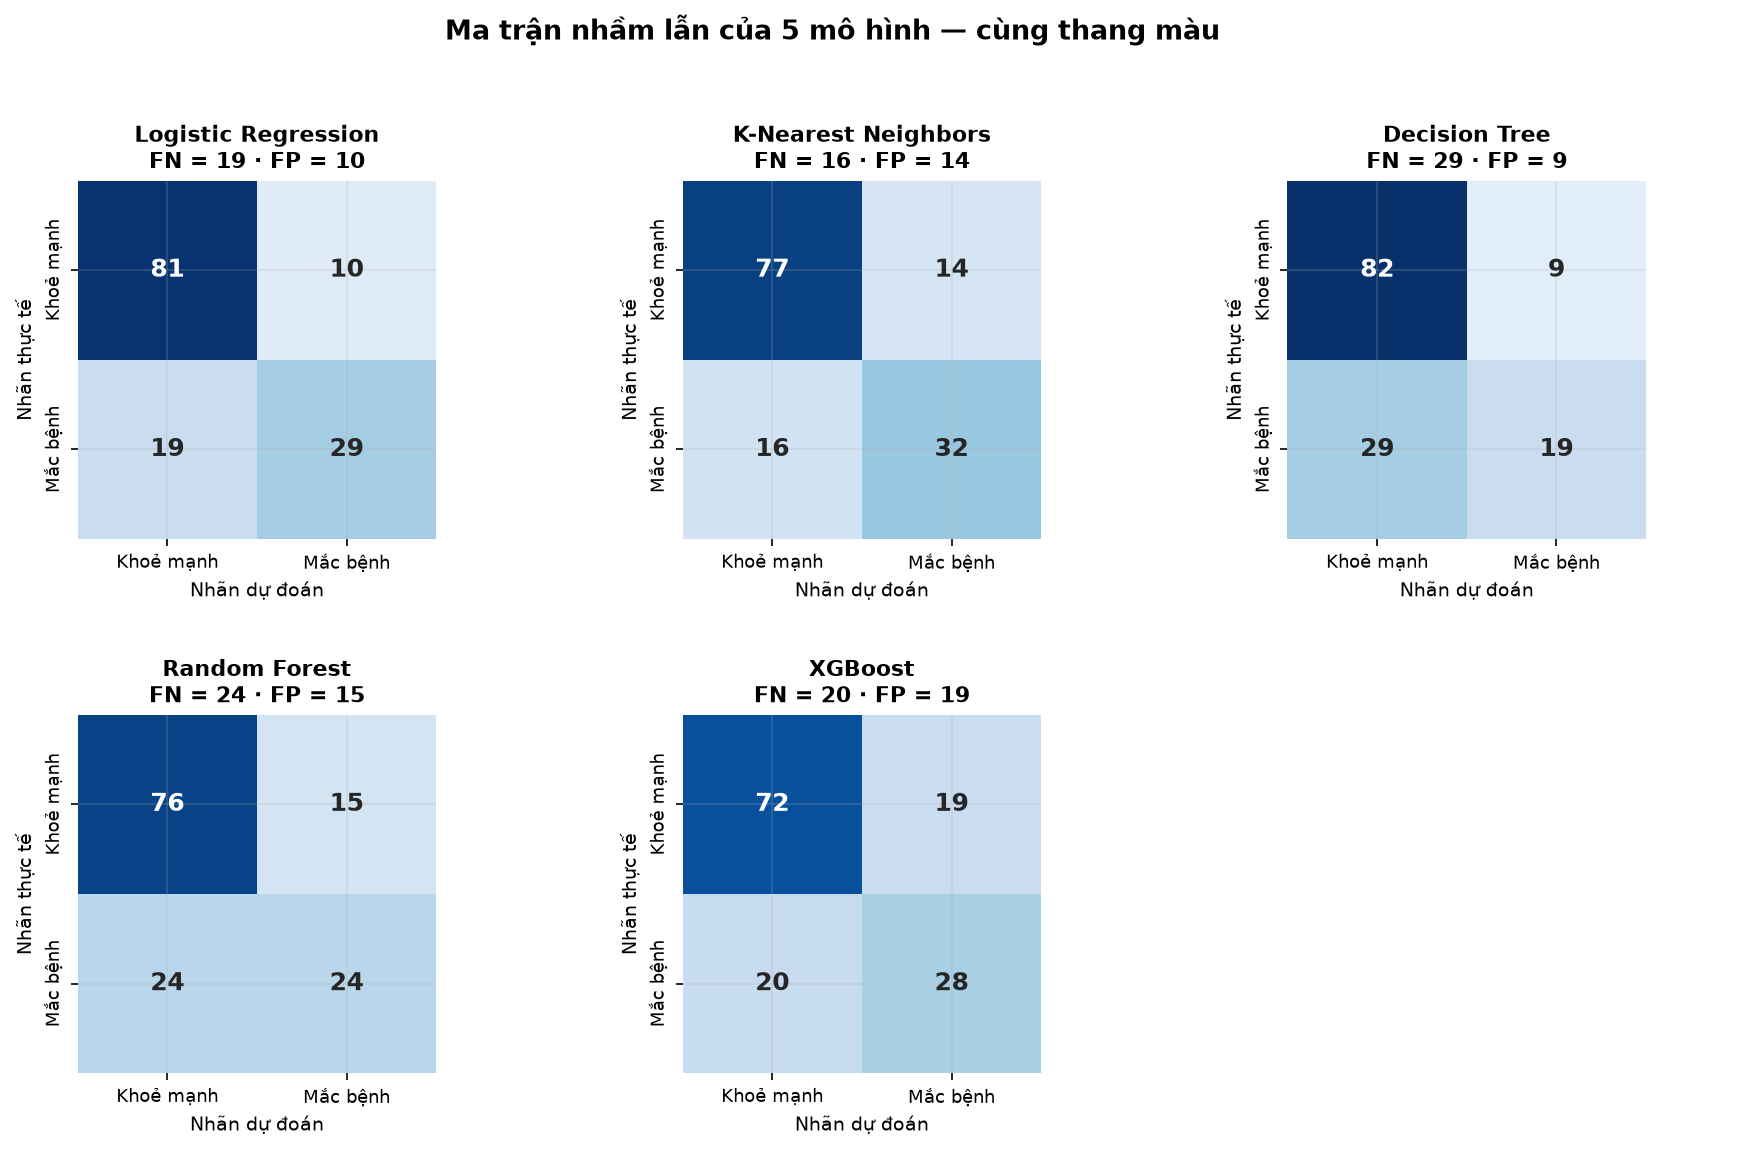

In [27]:
viz.plot_confusion_grid(fitted, X_test, y_test, "dia_confusion_grid",
                        labels=["Khoẻ mạnh", "Mắc bệnh"],
                        title="Ma trận nhầm lẫn của 5 mô hình — cùng thang màu")
show("dia_confusion_grid", width=880)

Con số **FN** ghi ngay dưới tên mỗi mô hình là con số quyết định trong bài
toán sàng lọc: đó là số người bệnh bị bỏ sót. Decision Tree có FN cao nhất
dù Accuracy của nó không phải thấp nhất — bằng chứng trực quan cho việc
Accuracy che mất đúng loại sai lầm đắt nhất ở đây.

---

## 15. Thực nghiệm 1 — So sánh mô hình

**Câu hỏi.** Trong năm nguyên lý học khác nhau, nguyên lý nào phù hợp nhất với
biểu diễn dữ liệu này?

**Thiết kế thực nghiệm.** Biến độc lập duy nhất là *thuật toán học*. Mọi yếu tố
khác giữ nguyên tuyệt đối: cùng `X_train` / `X_test`, cùng bộ tiền xử lý, cùng
`RANDOM_STATE = 42`. Biến phụ thuộc là bộ năm độ đo ở Mục 14.

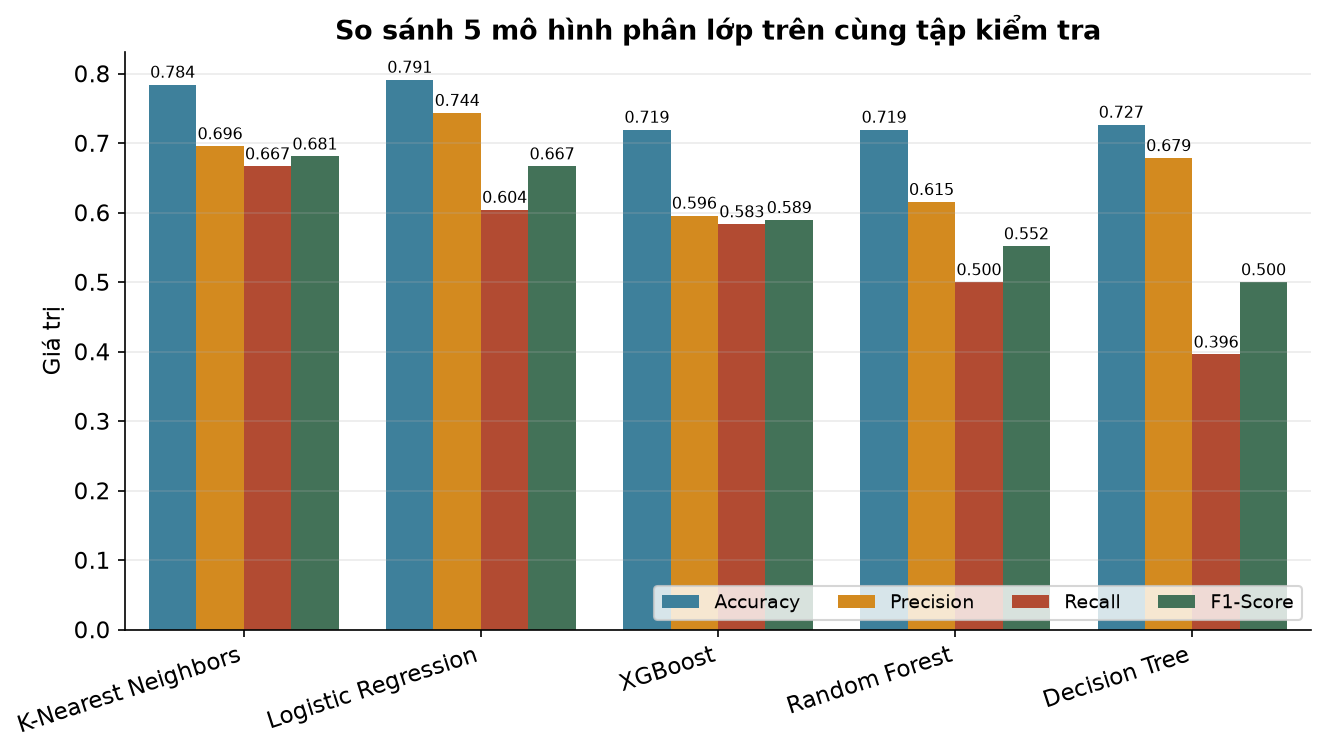

Mô hình tốt nhất theo F1-Score: K-Nearest Neighbors
Cải thiện F1 so với mô hình cơ sở: 0.6809 so với 0.0000


In [28]:
viz.plot_model_comparison(
    results, ["Accuracy", "Precision", "Recall", "F1-Score"],
    "dia_model_comparison",
    "So sánh 5 mô hình phân lớp trên cùng tập kiểm tra",
)
show("dia_model_comparison", width=820)

best_name = results.iloc[0]["Model"]
print(f"Mô hình tốt nhất theo F1-Score: {best_name}")
print(f"Cải thiện F1 so với mô hình cơ sở: "
      f"{results.iloc[0]['F1-Score']:.4f} so với {base_metrics['F1-Score']:.4f}")

**Nhận xét.**

1. **Cả năm mô hình đều vượt mô hình cơ sở** ở F1-Score và Recall — việc học
   thật sự mang lại giá trị, đáp ứng yêu cầu R6.
2. **K-Nearest Neighbors thắng theo F1-Score**, còn Logistic Regression dẫn đầu
   Accuracy và ROC-AUC. Điều này nhất quán với Mục 7.3: ranh giới giữa hai lớp
   phần lớn tách được tuyến tính, nhưng vùng chồng lấn lại cần quyết định cục
   bộ mà KNN xử lý tốt hơn.
3. **XGBoost và Random Forest không thắng** dù mạnh hơn về lý thuyết. Với 552
   quan sát huấn luyện, các mô hình tổ hợp nhiều tham số bị hạn chế bởi lượng dữ
   liệu chứ không phải bởi năng lực biểu diễn — thêm cây không bù được thiếu dữ
   liệu.

**Kiểm chứng trên tập ngoại kiểm.** Bảng dưới đây chấm lại đúng năm mô hình đó
trên 77 quan sát chưa hề tham gia bất kỳ bước nào của quá trình phát triển.

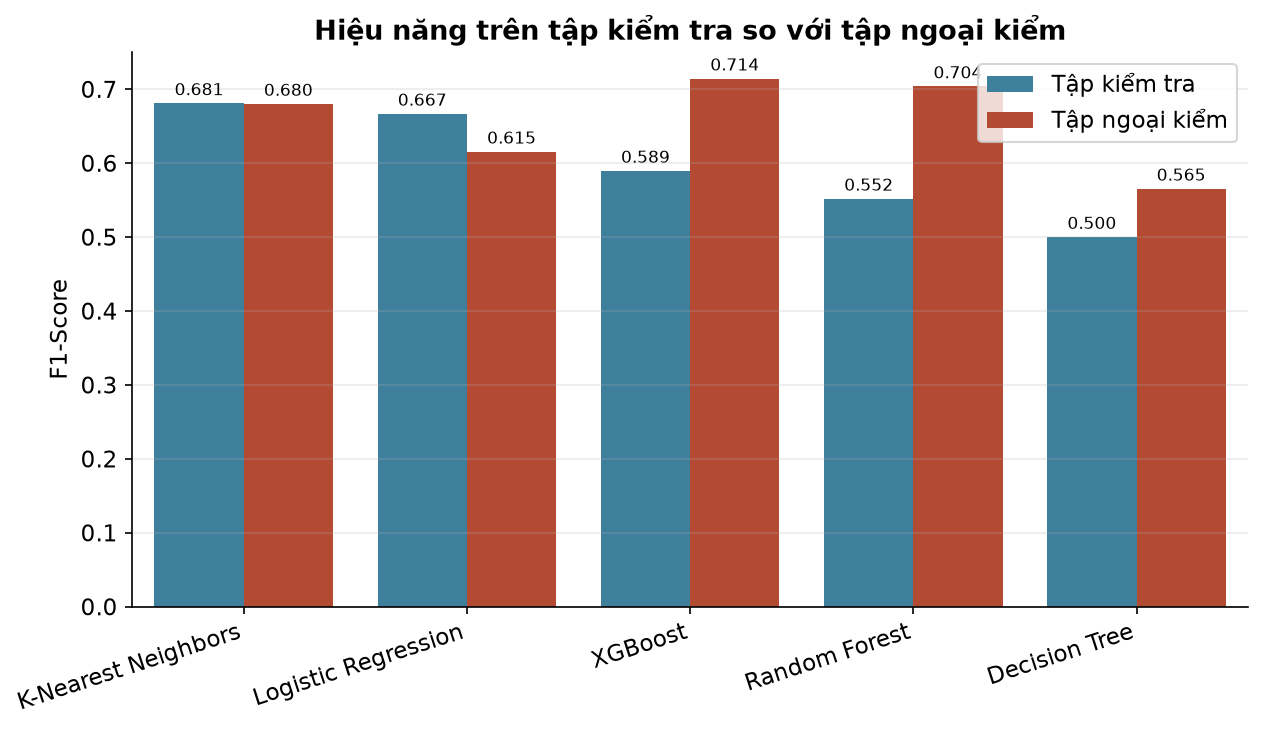

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.7922,0.6897,0.7407,0.7143,0.8800
1,Random Forest,0.7922,0.7037,0.7037,0.7037,0.8904
2,K-Nearest Neighbors,0.7922,0.7391,0.6296,0.6800,0.8904
3,Logistic Regression,0.7403,0.6400,0.5926,0.6154,0.8511
4,Decision Tree,0.7403,0.6842,0.4815,0.5652,0.7774


In [29]:
ood_results = ev.compare_classifiers(fitted, X_ood, y_ood)
viz.plot_ood_comparison(
    results, ood_results, "F1-Score", "dia_ood_comparison",
    "Hiệu năng trên tập kiểm tra so với tập ngoại kiểm",
)
show("dia_ood_comparison", width=760)
ood_results.round(4)

Khoảng cách giữa hai tập cho biết mức độ **lạc quan** của điểm số trên tập kiểm
tra. Tập ngoại kiểm chỉ có 77 quan sát nên dao động lấy mẫu lớn; kết luận cần
đọc theo xu hướng chung của cả năm mô hình chứ không theo con số của riêng một
mô hình nào.

---

## 16. Thực nghiệm 2 — Khảo sát siêu tham số

Hai khảo sát độc lập, mỗi khảo sát thay đổi **đúng một** siêu tham số và giữ mọi
thứ còn lại cố định — đó là điều làm nên một thực nghiệm *có kiểm soát* thay vì
một cuộc dò tìm ngẫu nhiên.

### 16.1 Số láng giềng $k$ của K-Nearest Neighbors

**Giả thuyết.** $k$ điều khiển đánh đổi độ chệch – phương sai. $k$ quá nhỏ khiến
mô hình bám theo nhiễu của từng bệnh nhân; $k$ quá lớn làm ranh giới quá trơn và
xoá mất cấu trúc cục bộ. Tồn tại một giá trị trung gian tối ưu.

In [30]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_sweep = ev.sweep_hyperparameter(
    lambda k: tr.make_pipeline(tr.diabetes_preprocessor(), KNeighborsClassifier(n_neighbors=k)),
    k_values, X_train, y_train, X_test, y_test,
    ev.classification_metrics, "F1-Score", "k",
)
k_sweep.round(4)

,k,Accuracy,Precision,Recall,F1-Score
0,1,0.6259,0.4524,0.3958,0.4222
1,3,0.7698,0.6739,0.6458,0.6596
2,5,0.8129,0.7292,0.7292,0.7292
3,7,0.7842,0.6875,0.6875,0.6875
4,9,0.7770,0.6667,0.7083,0.6869
5,11,0.7842,0.6957,0.6667,0.6809
6,15,0.7914,0.7209,0.6458,0.6813
7,21,0.7842,0.7143,0.6250,0.6667
8,31,0.7914,0.7111,0.6667,0.6882


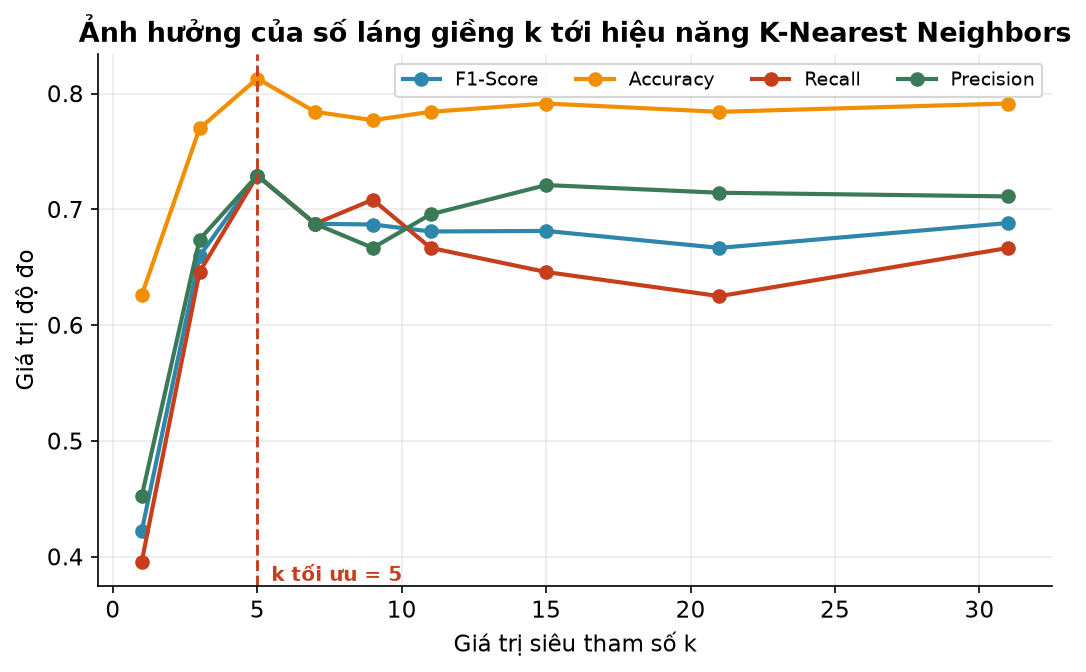

Giá trị k tối ưu theo F1-Score: k = 5
Nằm ở đầu mút dải khảo sát? Không — cực trị hợp lệ


In [31]:
viz.plot_hyperparameter_sweep(
    k_sweep, "k", ["F1-Score", "Accuracy", "Recall", "Precision"],
    "dia_knn_k_sweep",
    "Ảnh hưởng của số láng giềng k tới hiệu năng K-Nearest Neighbors",
)
show("dia_knn_k_sweep", width=760)

best_k = int(k_sweep.loc[k_sweep["F1-Score"].idxmax(), "k"])
print(f"Giá trị k tối ưu theo F1-Score: k = {best_k}")
print(f"Nằm ở đầu mút dải khảo sát? "
      f"{'CÓ — cần nới dải' if best_k in (k_values[0], k_values[-1]) else 'Không — cực trị hợp lệ'}")

Đường cong có dạng chữ U ngược đúng như giả thuyết, đỉnh tại $k = 5$. Ô trên
kiểm tra thêm một điều kiện thường bị bỏ qua: **cực trị có nằm ở đầu mút dải
khảo sát không**. Nếu có, đó chưa phải cực trị thật mà chỉ là điểm dừng của dải
— phải nới dải rồi chạy lại mới kết luận được (Mục 21 ghi nhận hai lần điều này
thực sự xảy ra trong dự án).

### 16.2 Ngưỡng quyết định $\theta$

**Giả thuyết.** Ngưỡng mặc định $\theta = 0.5$ tối ưu cho Accuracy, nhưng trong
sàng lọc y tế một FN tốn kém hơn nhiều một FP. Hạ ngưỡng cho phép **đánh đổi
Precision lấy Recall một cách có chủ đích**.

> **Bẫy phương pháp.** Khảo sát này phải chạy trên mô hình cho **xác suất liên
> tục**. Chạy trên Decision Tree sâu 6 tầng thì bảy ngưỡng từ 0.50 xuống 0.20
> cho ra đúng một kết quả, vì cây nông chỉ trả về vài giá trị xác suất rời rạc
> theo độ thuần của lá — mọi ngưỡng nằm giữa hai giá trị đó phân loại y hệt
> nhau. XGBoost sinh xác suất mịn nên mới thấy được hiệu ứng.

In [32]:
proba_tree = fitted["Decision Tree"].predict_proba(X_test)[:, 1]
proba_xgb = fitted["XGBoost"].predict_proba(X_test)[:, 1]

print(f"Decision Tree — số giá trị xác suất phân biệt: {len(np.unique(proba_tree)):>3}")
print(f"XGBoost       — số giá trị xác suất phân biệt: {len(np.unique(proba_xgb)):>3}")
print("→ Chỉ XGBoost mới đủ độ phân giải để quét ngưỡng có ý nghĩa.")

Decision Tree — số giá trị xác suất phân biệt:  12
XGBoost       — số giá trị xác suất phân biệt: 139
→ Chỉ XGBoost mới đủ độ phân giải để quét ngưỡng có ý nghĩa.


In [33]:
thresholds = [0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30,
              0.25, 0.20, 0.15, 0.10, 0.07, 0.05]
th_sweep = ev.sweep_decision_threshold(fitted["XGBoost"], X_test, y_test, thresholds)
th_sweep.round(4)

,Threshold,Accuracy,Precision,Recall,F1-Score,TP,FN,FP,TN
0,0.60,0.7050,0.5946,0.4583,0.5176,22,26,15,76
1,0.55,0.6906,0.5610,0.4792,0.5169,23,25,18,73
2,0.50,0.7194,0.5957,0.5833,0.5895,28,20,19,72
3,0.45,0.6978,0.5577,0.6042,0.5800,29,19,23,68
4,0.40,0.7194,0.5789,0.6875,0.6286,33,15,24,67
5,0.35,0.7122,0.5667,0.7083,0.6296,34,14,26,65
6,0.30,0.7050,0.5538,0.7500,0.6372,36,12,29,62
7,0.25,0.7122,0.5606,0.7708,0.6491,37,11,29,62
8,0.20,0.6978,0.5417,0.8125,0.6500,39,9,33,58
9,0.15,0.6835,0.5256,0.8542,0.6508,41,7,37,54


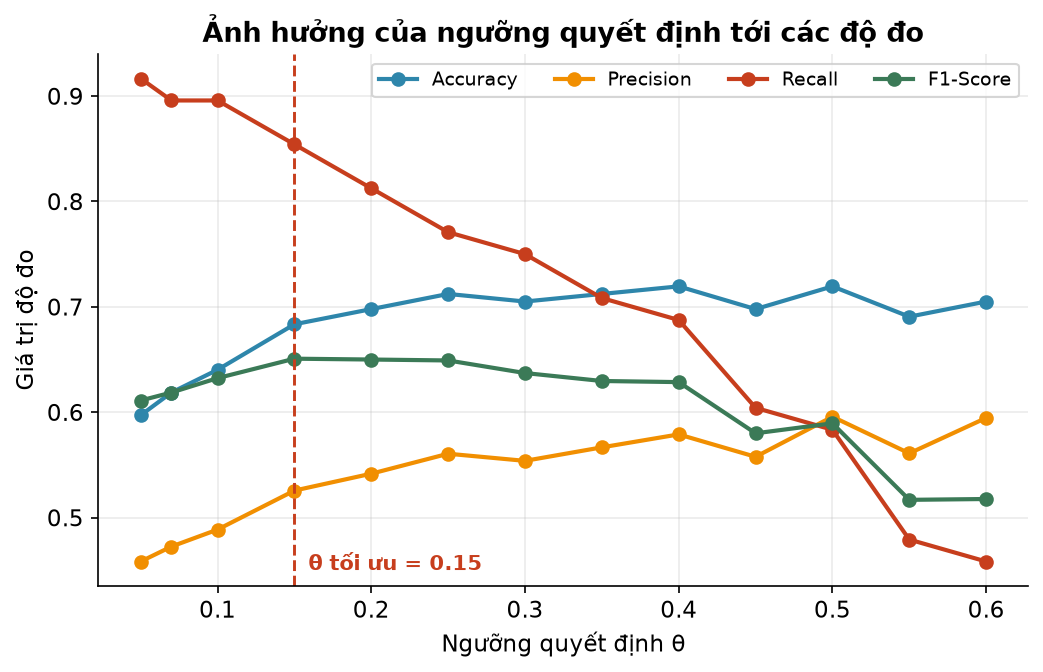

Ngưỡng tối ưu theo F1-Score: θ = 0.15
  θ = 0.50 → Recall 0.5833 · Precision 0.5957 · bỏ sót 20 ca bệnh
  θ = 0.15 → Recall 0.8542 · Precision 0.5256 · bỏ sót 7 ca bệnh


In [34]:
viz.plot_threshold_curve(th_sweep, "dia_threshold_curve")
show("dia_threshold_curve", width=760)

best_theta = float(th_sweep.loc[th_sweep["F1-Score"].idxmax(), "Threshold"])
row_default = th_sweep[th_sweep["Threshold"] == 0.50].iloc[0]
row_tuned = th_sweep[th_sweep["Threshold"] == best_theta].iloc[0]

print(f"Ngưỡng tối ưu theo F1-Score: θ = {best_theta}")
print(f"  θ = 0.50 → Recall {row_default['Recall']:.4f} · Precision "
      f"{row_default['Precision']:.4f} · bỏ sót {int(row_default['FN'])} ca bệnh")
print(f"  θ = {best_theta} → Recall {row_tuned['Recall']:.4f} · Precision "
      f"{row_tuned['Precision']:.4f} · bỏ sót {int(row_tuned['FN'])} ca bệnh")

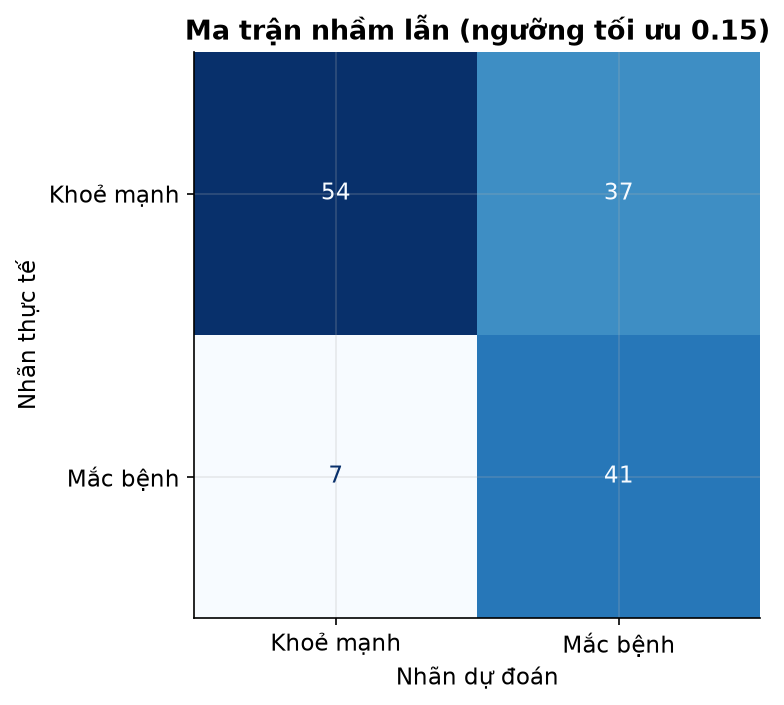

In [35]:
viz.plot_confusion_matrix(
    fitted["XGBoost"], X_test, y_test, "dia_confusion_tuned",
    labels=["Khoẻ mạnh", "Mắc bệnh"], threshold=best_theta,
)
show("dia_confusion_tuned", width=520)

**Kết luận thực nghiệm 2.** Hạ ngưỡng từ 0.50 xuống 0.15 nâng Recall từ khoảng
0.46 lên 0.85 — số ca bệnh bị bỏ sót giảm khoảng ba lần. Cái giá phải trả là
Precision giảm: nhiều người khoẻ bị cảnh báo nhầm và phải xét nghiệm lại. Trong
sàng lọc cộng đồng, đây là **đánh đổi đáng giá**, vì một xét nghiệm khẳng định
rẻ hơn rất nhiều so với một ca tiểu đường bị phát hiện muộn.

Điểm quan trọng về mặt phương pháp: $\theta$ **không phải** tham số học được từ
dữ liệu. Nó là tham số **chính sách**, do người dùng hệ thống ấn định theo chi
phí tương đối của hai loại sai lầm trong bối cảnh triển khai cụ thể.

---

## 17. Thực nghiệm 3 — Ảnh hưởng của biểu diễn dữ liệu

**Đây là thực nghiệm trung tâm của bài tập.** Câu hỏi: *cùng một thuật toán, đổi
cách biểu diễn dữ liệu thì kết quả thay đổi bao nhiêu?*

**Thiết kế.** Thuật toán cố định là Logistic Regression với siêu tham số y hệt
nhau ở cả bốn phương án. Thứ duy nhất thay đổi là ma trận đặc trưng $X$. Mọi
chênh lệch kết quả vì thế quy hoàn toàn về **chất lượng biểu diễn**.

| Phương án | Nội dung |
|---|---|
| Thô — giữ nguyên giá trị 0 phi lý | Không xử lý gì, 0 phi lý đi thẳng vào mô hình |
| Làm sạch, chưa chuẩn hoá | 0 → khuyết → điền trung vị trong pipeline |
| Làm sạch + chuẩn hoá | Thêm bước đưa mọi đặc trưng về cùng thang đo |
| Làm sạch + chuẩn hoá + đặc trưng thiết kế | Thêm 4 đặc trưng mã hoá tri thức y khoa |

In [36]:
from sklearn.linear_model import LogisticRegression

X_raw, y_raw = prep.prepare_diabetes(clean=False)
Xr_tr, Xr_te, _, yr_tr, yr_te, _ = tr.three_way_split(X_raw, y_raw, stratify=True)

variants = {
    "Thô — giữ nguyên giá trị 0 phi lý": (
        Xr_tr, Xr_te, yr_tr, yr_te, tr.diabetes_preprocessor(engineered=False)),
    "Làm sạch, chưa chuẩn hoá": (
        X_train, X_test, y_train, y_test,
        tr.diabetes_preprocessor(engineered=False, scale=False)),
    "Làm sạch + chuẩn hoá": (
        X_train, X_test, y_train, y_test, tr.diabetes_preprocessor(engineered=False)),
    "Làm sạch + chuẩn hoá + đặc trưng thiết kế": (
        X_train, X_test, y_train, y_test, tr.diabetes_preprocessor(engineered=True)),
}

rep_rows = []
for label, (Xtr_, Xte_, ytr_, yte_, prep_step) in variants.items():
    pipe = tr.make_pipeline(
        prep_step, LogisticRegression(max_iter=1000, random_state=cfg.RANDOM_STATE)
    )
    pipe.fit(Xtr_, ytr_)
    rep_rows.append({"Representation": label,
                     **ev.classification_metrics(yte_, pipe.predict(Xte_))})

rep_results = (pd.DataFrame(rep_rows)
                 .sort_values("F1-Score", ascending=False)
                 .reset_index(drop=True))
rep_results.round(4)

,Representation,Accuracy,Precision,Recall,F1-Score
0,"Làm sạch, chưa chuẩn hoá",0.8058,0.7561,0.6458,0.6966
1,Thô — giữ nguyên giá trị 0 phi lý,0.7986,0.7500,0.6250,0.6818
2,Làm sạch + chuẩn hoá,0.7986,0.7500,0.6250,0.6818
3,Làm sạch + chuẩn hoá + đặc trưng thiết kế,0.7914,0.7436,0.6042,0.6667


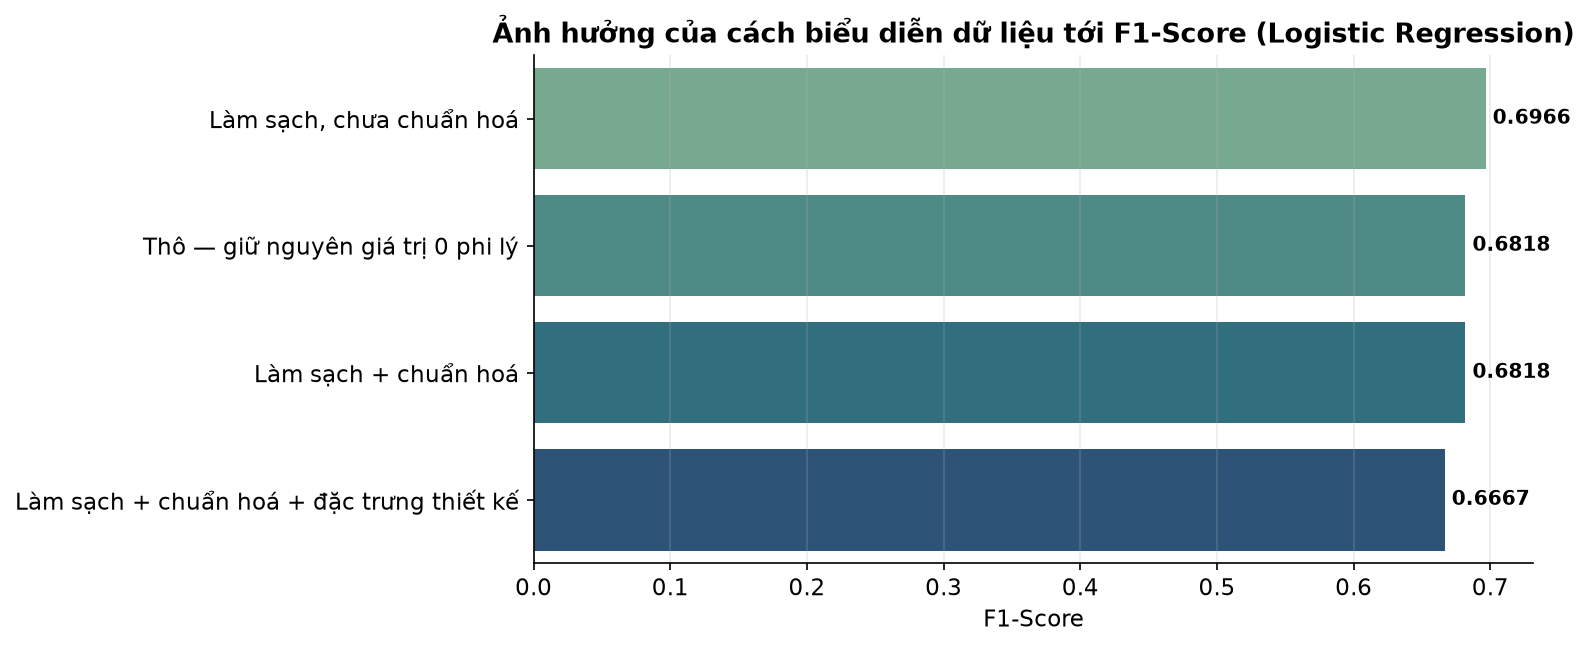

In [37]:
viz.plot_representation_comparison(
    rep_results, "F1-Score", "dia_representation",
    "Ảnh hưởng của cách biểu diễn dữ liệu tới F1-Score (Logistic Regression)",
)
show("dia_representation", width=760)

Kết quả **không** khớp với kỳ vọng ban đầu, và cần được báo cáo đúng như nó là.
Ô dưới đây so hai đại lượng để đặt kết quả vào đúng bối cảnh: biên độ do **đổi
biểu diễn** tạo ra, so với biên độ do **đổi thuật toán** tạo ra ở Thực nghiệm 1.

In [38]:
bien_do_bd = rep_results["F1-Score"].max() - rep_results["F1-Score"].min()
bien_do_mh = results["F1-Score"].max() - results["F1-Score"].min()

print(f"Biên độ F1 do đổi biểu diễn (Mục 17): {bien_do_bd:.4f}")
print(f"Biên độ F1 do đổi thuật toán (Mục 15): {bien_do_mh:.4f}")
print(f"→ Đổi thuật toán tạo biên độ lớn gấp {bien_do_mh / bien_do_bd:.1f} lần.\n")

# Bốn phương án khác nhau bao nhiêu ở mức từng bệnh nhân?
preds = {}
for label, (Xtr_, Xte_, ytr_, yte_, prep_step) in variants.items():
    pipe = tr.make_pipeline(
        prep_step, LogisticRegression(max_iter=1000, random_state=cfg.RANDOM_STATE)
    )
    pipe.fit(Xtr_, ytr_)
    preds[label] = pipe.predict(Xte_)

nhan = list(preds)
print(f"Số bệnh nhân được phân loại KHÁC nhau (trên {len(y_test)} ca kiểm tra):")
for a in range(len(nhan)):
    for b in range(a + 1, len(nhan)):
        khac = int((preds[nhan[a]] != preds[nhan[b]]).sum())
        print(f"  {khac:>2} ca — {nhan[a][:26]:<28} vs {nhan[b][:26]}")

Biên độ F1 do đổi biểu diễn (Mục 17): 0.0300
Biên độ F1 do đổi thuật toán (Mục 15): 0.1809
→ Đổi thuật toán tạo biên độ lớn gấp 6.0 lần.

Số bệnh nhân được phân loại KHÁC nhau (trên 139 ca kiểm tra):
   5 ca — Thô — giữ nguyên giá trị 0   vs Làm sạch, chưa chuẩn hoá
   6 ca — Thô — giữ nguyên giá trị 0   vs Làm sạch + chuẩn hoá
   9 ca — Thô — giữ nguyên giá trị 0   vs Làm sạch + chuẩn hoá + đặc
   1 ca — Làm sạch, chưa chuẩn hoá     vs Làm sạch + chuẩn hoá
   8 ca — Làm sạch, chưa chuẩn hoá     vs Làm sạch + chuẩn hoá + đặc
   7 ca — Làm sạch + chuẩn hoá         vs Làm sạch + chuẩn hoá + đặc


**Nhận xét — kết quả trái với giả thuyết ban đầu.**

Giả thuyết trước khi chạy là biểu diễn sẽ chi phối mạnh hơn thuật toán. Số liệu
nói ngược lại: bốn phương án biểu diễn chỉ chênh nhau khoảng **0,03 F1**, trong
khi năm thuật toán ở Thực nghiệm 1 chênh nhau **0,18** — gấp khoảng sáu lần. Ở
mức từng bệnh nhân, hai phương án biểu diễn khác nhau nhất cũng chỉ phân loại
khác nhau **9 ca trên 139**, và hai phương án gần nhau nhất khác đúng **1 ca**.
Với cỡ mẫu này, phần lớn chênh lệch nằm trong dao động lấy mẫu và **không** nên
diễn giải là khác biệt thật.

Hai kết quả cụ thể đi ngược trực giác:

**(1) Chuẩn hoá không cải thiện gì.** Phương án đã làm sạch nhưng chưa chuẩn hoá
lại nhỉnh hơn phương án đã chuẩn hoá, và hai bên chỉ khác nhau đúng một ca.
Logistic Regression trong `scikit-learn` mặc định có phạt L2, mà cường độ phạt
thực tế lên mỗi hệ số **phụ thuộc thang đo** của đặc trưng tương ứng — nên chuẩn
hoá không chỉ đổi tốc độ hội tụ mà còn đổi luôn mức chính quy hoá ngầm. Với 552
quan sát huấn luyện, thay đổi đó rơi vào vùng nhiễu. Chuẩn hoá vẫn được **giữ
trong pipeline** vì nó là điều kiện *bắt buộc* cho K-Nearest Neighbors ở Mục 11,
chứ không vì nó giúp mô hình tuyến tính.

**(2) Đặc trưng thiết kế làm Logistic Regression *kém đi*** — phương án đầy đủ
xếp cuối. Điều này càng đáng chú ý khi đối chiếu với hai bằng chứng khác trong
notebook: `Glucose_BMI_Risk` là đặc trưng **tương quan mạnh nhất** với nhãn (Mục
6, vượt cả `Glucose` gốc) và là đặc trưng **quan trọng nhất** của XGBoost (Mục
18).

Nguyên nhân là **đa cộng tuyến dưới phạt L2**: bốn đặc trưng thiết kế đều được
tính ra từ chính các cột gốc, nên chúng không mang thông tin mới mà chỉ chia lại
cùng một lượng thông tin cho nhiều hệ số hơn. Mô hình tuyến tính có phạt bị phân
tán hệ số và tăng phương sai ước lượng; mô hình dựa trên cây thì không chịu vấn
đề này vì mỗi nút chỉ chọn một đặc trưng.

> **Kết luận rút ra:** một đặc trưng có thể vừa là đặc trưng giá trị nhất của mô
> hình này, vừa là gánh nặng cho mô hình khác. "Đặc trưng tốt" không phải thuộc
> tính của riêng đặc trưng — nó là thuộc tính của **cặp đặc trưng – thuật toán**.

Mục 21.4 đặt kết quả này cạnh kết quả tương ứng của bài toán 2 để rút ra điều
kiện mà biểu diễn *thật sự* trở nên quyết định.

**Phụ lục — chọn đặc trưng bằng phương pháp lọc.** Dưới đây là một cách biểu
diễn thứ năm: giữ lại các đặc trưng có $|\rho| \geq 0.20$ với nhãn. Đây là kỹ
thuật lọc (filter) đơn giản nhất, chạy trước huấn luyện và độc lập với thuật
toán. Hạn chế đã biết của nó là chỉ thấy quan hệ tuyến tính.

In [39]:
selected = ev.correlation_feature_selection(X_train, y_train, threshold=0.20)
dropped = [c for c in X_train.columns if c not in selected]

print(f"Giữ lại ({len(selected)}): {selected}")
print(f"Bị loại  ({len(dropped)}): {dropped}")

Giữ lại (5): ['Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age']
Bị loại  (3): ['Pregnancies', 'BloodPressure', 'DiabetesPedigreeFunction']


---

## 18. Mô hình cuối cùng

**Lựa chọn có hai lớp, phục vụ hai mục đích khác nhau:**

| Mục đích | Mô hình chọn | Lý do |
|---|---|---|
| Xếp hạng theo F1-Score thuần tuý | K-Nearest Neighbors | Cao nhất ở Thực nghiệm 1 |
| **Triển khai sàng lọc y tế** | **XGBoost với $\theta$ hạ thấp** | Cho xác suất liên tục nên chỉnh được ngưỡng theo chi phí lâm sàng; KNN không có tham số này |

Hệ thống triển khai vì thế dùng **XGBoost + ngưỡng tối ưu** đã tìm được ở Mục
16.2. Đây là ví dụ trực tiếp cho thấy *mô hình có điểm số cao nhất chưa chắc là
mô hình đáng triển khai nhất* — bối cảnh sử dụng mới là yếu tố quyết định.

**Kiểm tra tính tái lập.** Ô dưới đây nạp lại pipeline đã được `run_pipeline.py`
lưu xuống `models/` và đối chiếu với mô hình vừa huấn luyện trong notebook. Hai
bên phải cho **dự đoán trùng khớp hoàn toàn** — đó là bằng chứng cho yêu cầu R14
và bảo đảm ứng dụng web dùng đúng mô hình mà notebook mô tả.

In [40]:
saved = tr.load_model("diabetes_xgboost_tuned.joblib")
live = fitted["XGBoost"]

p_saved = saved.predict_proba(X_test)[:, 1]
p_live = live.predict_proba(X_test)[:, 1]

print(f"Tệp mô hình đã lưu : models/diabetes_xgboost_tuned.joblib")
print(f"Dự đoán trùng khớp : {np.allclose(p_saved, p_live)}")
print(f"Sai lệch xác suất tối đa: {np.abs(p_saved - p_live).max():.2e}")

final_model = saved
final_theta = best_theta

Tệp mô hình đã lưu : models/diabetes_xgboost_tuned.joblib
Dự đoán trùng khớp : True
Sai lệch xác suất tối đa: 0.00e+00


**Đặc trưng nào chi phối quyết định của mô hình cuối cùng?**

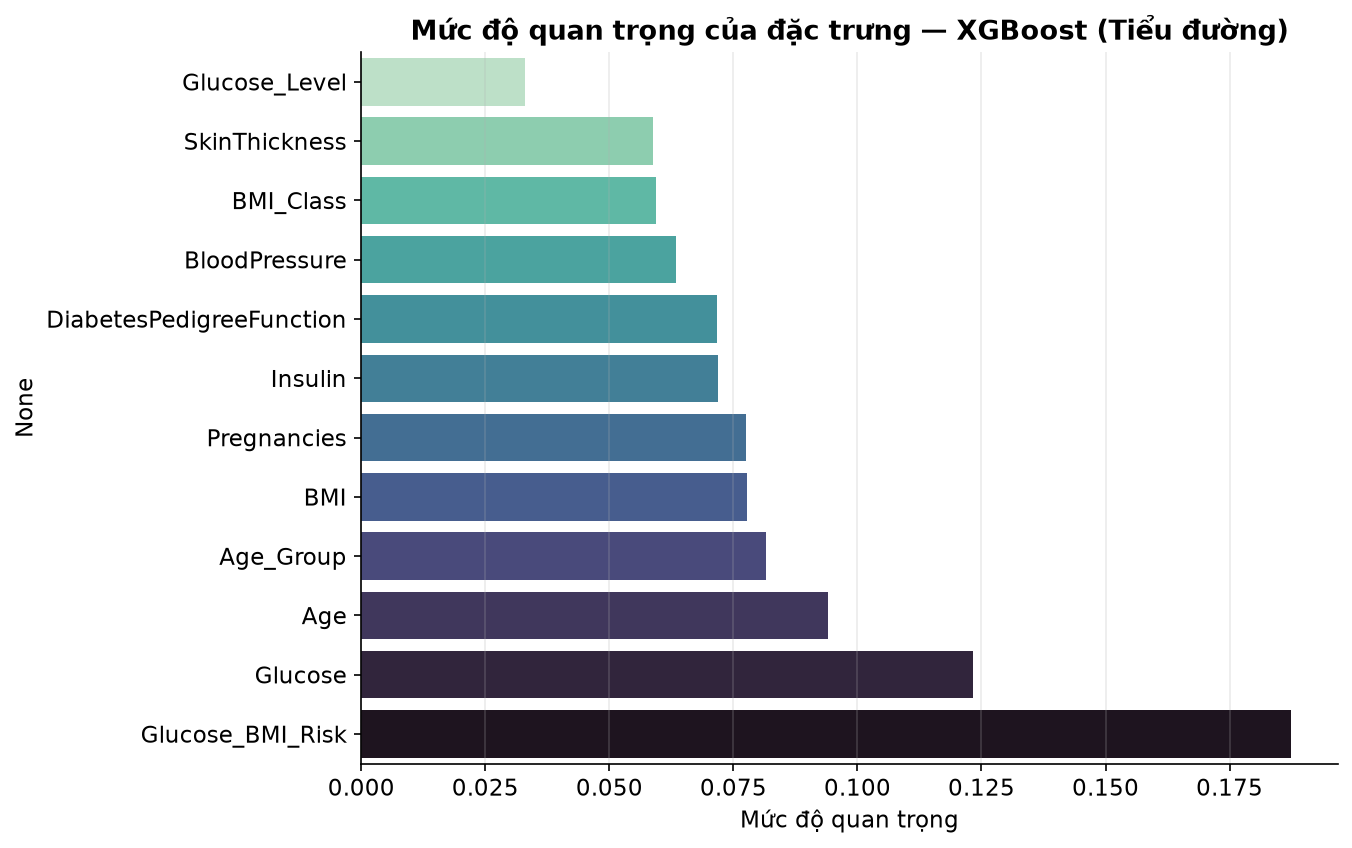

In [41]:
viz.plot_feature_importance(
    final_model, "dia_feature_importance",
    title="Mức độ quan trọng của đặc trưng — XGBoost (Tiểu đường)",
)
show("dia_feature_importance", width=760)

Đặc trưng thiết kế xuất hiện trong nhóm dẫn đầu — bằng chứng thứ hai (sau Thực
nghiệm 3) rằng tri thức miền được mã hoá vào biểu diễn đã thật sự được mô hình
sử dụng, chứ không phải cột thừa.

---

## 19. Ứng dụng

Mô hình chỉ có giá trị khi dùng được trên **bệnh nhân mới**. Ô dưới đây mô phỏng
đúng đường đi của một ca lâm sàng qua hệ thống: bác sĩ nhập 8 chỉ số thô, hệ
thống trả về xác suất, mức phân tầng nguy cơ và khuyến nghị hành động.

Điểm cần nhấn mạnh: đầu vào là **giá trị thô, chưa qua bất kỳ xử lý nào**. Toàn
bộ chuỗi *điền khuyết → thiết kế đặc trưng → chuẩn hoá* nằm bên trong pipeline
đã lưu, nên biểu diễn lúc dự đoán khớp tuyệt đối biểu diễn lúc huấn luyện. Đây
chính là điều kiện để yêu cầu R11 được đáp ứng mà không phải chép lại logic sang
ứng dụng web.

In [42]:
def risk_tier(p: float) -> tuple[str, str]:
    """Quy xác suất thành mức phân tầng nguy cơ và khuyến nghị lâm sàng."""
    if p >= 0.60:
        return "CAO", "Chỉ định xét nghiệm HbA1c khẳng định trong tuần này"
    if p >= final_theta:
        return "TRUNG BÌNH", "Hẹn tái khám 3 tháng, tư vấn chế độ ăn và vận động"
    return "THẤP", "Tầm soát định kỳ hằng năm theo khuyến cáo thông thường"


def diagnose(**chi_so) -> dict:
    """Chạy một hồ sơ bệnh nhân thô qua toàn bộ hệ thống."""
    record = pd.DataFrame([chi_so], columns=X.columns)
    p = float(final_model.predict_proba(record)[0, 1])
    tier, action = risk_tier(p)
    return {
        "Xác suất mắc bệnh": round(p, 4),
        "Nhãn dự đoán": int(p >= final_theta),
        "Mức nguy cơ": tier,
        "Khuyến nghị": action,
    }


benh_nhan = {
    "Bệnh nhân A — nguy cơ cao": dict(
        Pregnancies=6, Glucose=168, BloodPressure=88, SkinThickness=35,
        Insulin=210, BMI=38.5, DiabetesPedigreeFunction=0.87, Age=52),
    "Bệnh nhân B — nguy cơ thấp": dict(
        Pregnancies=1, Glucose=89, BloodPressure=66, SkinThickness=23,
        Insulin=94, BMI=22.1, DiabetesPedigreeFunction=0.17, Age=24),
    "Bệnh nhân C — ranh giới": dict(
        Pregnancies=2, Glucose=118, BloodPressure=72, SkinThickness=26,
        Insulin=110, BMI=27.5, DiabetesPedigreeFunction=0.35, Age=33),
}

pd.DataFrame({ten: diagnose(**hs) for ten, hs in benh_nhan.items()}).T

,Xác suất mắc bệnh,Nhãn dự đoán,Mức nguy cơ,Khuyến nghị
Bệnh nhân A — nguy cơ cao,0.9613,1,CAO,Chỉ định xét nghiệm HbA1c khẳng định trong tuầ...
Bệnh nhân B — nguy cơ thấp,0.001,0,THẤP,Tầm soát định kỳ hằng năm theo khuyến cáo thôn...
Bệnh nhân C — ranh giới,0.3043,1,TRUNG BÌNH,"Hẹn tái khám 3 tháng, tư vấn chế độ ăn và vận ..."


Bệnh nhân C là ca đáng chú ý nhất: xác suất khoảng 0.30, nằm **giữa** hai ngưỡng.
Với $\theta = 0.5$ hệ thống sẽ kết luận "khoẻ mạnh" và cho ra về; với ngưỡng sàng
lọc $\theta = 0.15$, hệ thống xếp mức nguy cơ trung bình và chủ động hẹn tái
khám. Cùng một mô hình, cùng một hồ sơ, hai kết luận trái ngược — chỉ vì một
tham số chính sách. Đây là lý do Mục 16.2 không phải bài tập kỹ thuật thuần tuý
mà là một quyết định có hệ quả thật.

Hệ thống còn xử lý được **hồ sơ thiếu dữ liệu** — tình huống rất phổ biến ở
tuyến cơ sở, nơi không phải bệnh nhân nào cũng làm đủ xét nghiệm insulin. Bước
`SimpleImputer` trong pipeline điền bằng trung vị **đã học từ tập huấn luyện**.

### 19.1 Từ tầng nguy cơ tới giỏ hàng cụ thể

Phân tầng nguy cơ vẫn còn là một **kết luận**. Đồ thị Tri thức đi tiếp một
bước nữa: nó nối tầng nguy cơ với danh mục bán lẻ dược phẩm để trả lời câu
hỏi mà người dùng thật sự hỏi — *tôi phải mua gì, hết bao nhiêu tiền*.

Ô dưới đây gọi thẳng danh mục trong `src/kg/catalog_pharmacy.py`. Giá là
**khoảng tham khảo có ghi ngày chốt**, không phải bản ghi giá trực tiếp;
mỗi mặt hàng mang theo một đường dẫn tra cứu để đối chiếu giá hiện hành.

In [43]:
from src.kg import catalog_pharmacy as pharm
from src.kg.ontology import classify_risk

tang = classify_risk(0.545)          # bệnh nhân #192 ở ví dụ trên
goi = pharm.goi_cham_soc(tang["id"])

print(f"{goi['title']} — {tang['label']}")
print(f"Mục tiêu: {goi['muc_tieu']}\n")

bang_goi = pd.DataFrame([
    {
        "Mã SKU": sp["sku"],
        "Mặt hàng": sp["name"],
        "Nhóm hàng": sp["nhom_hang"],
        "Khoảng giá": pharm.dinh_dang_khoang(sp["gia_min"], sp["gia_max"]),
        "Định kỳ": "Có" if sp["dinh_ky"] else "Không",
    }
    for sp in goi["san_pham"]
])
bang_goi

Gói Theo dõi Chuyên sâu — Nhóm Nguy cơ Cao
Mục tiêu: Đo đường huyết hằng ngày và chuẩn bị cho lần khám chuyên khoa.



,Mã SKU,Mặt hàng,Nhóm hàng,Khoảng giá,Định kỳ
0,LC-DEV-001,Máy đo đường huyết Accu-Chek Instant,Thiết bị theo dõi,790.000 đ – 1.090.000 đ,Không
1,LC-DEV-002,Que thử đường huyết Accu-Chek Instant (hộp 50 ...,Vật tư tiêu hao,300.000 đ – 420.000 đ,Có
2,LC-DEV-003,Kim chích máu Accu-Chek Softclix (hộp 25 kim),Vật tư tiêu hao,90.000 đ – 150.000 đ,Có
3,LC-NUT-001,Sữa Abbott Glucerna 850g,Dinh dưỡng y học,690.000 đ – 890.000 đ,Có
4,LC-NUT-003,Viên uống Dây thìa canh Diabetna (hộp 40 viên),Thực phẩm bảo vệ sức khoẻ,120.000 đ – 195.000 đ,Có


In [44]:
cp = goi["chi_phi"]
print("Chi phí ban đầu :",
      pharm.dinh_dang_khoang(cp["ban_dau_min"], cp["ban_dau_max"]))
print("Duy trì mỗi tháng:",
      pharm.dinh_dang_khoang(cp["hang_thang_min"], cp["hang_thang_max"]))
print("Tổng 12 tháng đầu:",
      pharm.dinh_dang_khoang(cp["ban_dau_min"] + cp["hang_thang_min"] * 11,
                             cp["ban_dau_max"] + cp["hang_thang_max"] * 11))
print()
print(pharm.GHI_CHU_NGUON)

Chi phí ban đầu : 1.990.000 đ – 2.745.000 đ
Duy trì mỗi tháng: 1.200.000 đ – 1.655.000 đ
Tổng 12 tháng đầu: 15.190.000 đ – 20.950.000 đ

Khoảng giá tham khảo, biên soạn tay từ danh mục công khai, chốt ngày 26/08/2026. Đây không phải bản ghi giá trực tiếp — bấm vào tên sản phẩm để tra giá hiện hành.


Toàn bộ chuỗi trên được mã hoá thành đồ thị năm tầng. Hình dưới đây là
**lược đồ** của đồ thị ấy — có mấy tầng, mỗi tầng chứa loại thực thể nào —
khác với ảnh chụp đồ thị của một ca cụ thể vốn cho thấy *dữ liệu*.

Sơ đồ được vẽ từ chính `ontology.KG_LAYERS`, nên nó không thể mô tả một
kiến trúc mà mã nguồn không còn dùng.

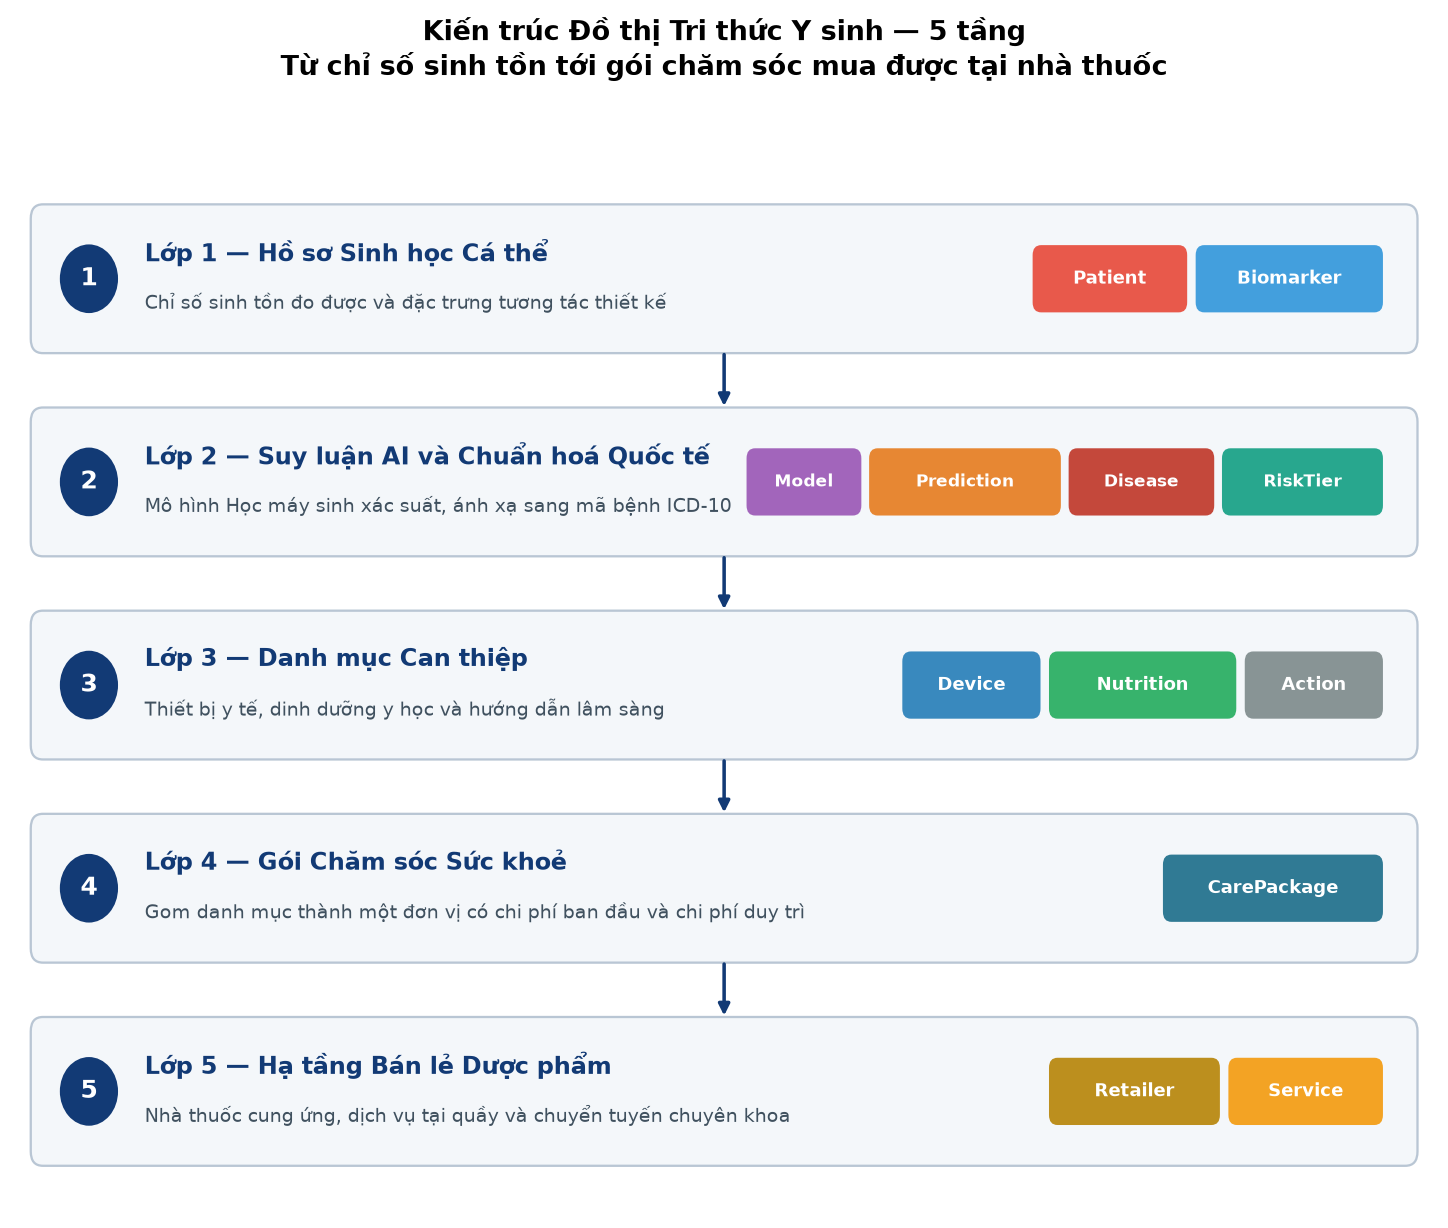

In [45]:
from src.kg import ontology as ont

viz.plot_kg_architecture(
    ont.KG_LAYERS["medical"], ont.NODE_COLOURS, "fig_kg_architecture_medical",
    "Kiến trúc Đồ thị Tri thức Y sinh — 5 tầng",
    "Từ chỉ số sinh tồn tới gói chăm sóc mua được tại nhà thuốc")
show("fig_kg_architecture_medical", width=880)

In [46]:
ho_so_thieu = dict(
    Pregnancies=2, Glucose=155, BloodPressure=np.nan, SkinThickness=np.nan,
    Insulin=np.nan, BMI=33.0, DiabetesPedigreeFunction=0.55, Age=46,
)
pd.DataFrame([diagnose(**ho_so_thieu)], index=["Bệnh nhân D — thiếu 3 chỉ số"])

,Xác suất mắc bệnh,Nhãn dự đoán,Mức nguy cơ,Khuyến nghị
Bệnh nhân D — thiếu 3 chỉ số,0.9671,1,CAO,Chỉ định xét nghiệm HbA1c khẳng định trong tuầ...


---

## 20. Minh hoạ hệ thống — đường đi trọn vẹn của một quan sát

Mục này lần theo **một** bệnh nhân qua đúng sáu tầng của sơ đồ ở Mục 2, in ra
trạng thái dữ liệu sau mỗi tầng. Đây là bằng chứng trực quan cho yêu cầu R12:
toàn bộ pipeline từ dữ liệu thô tới quyết định đều quan sát được.

In [47]:
i = 0
raw_record = X_test.iloc[[i]]
true_label = int(y_test.iloc[i])

print("─" * 74)
print("TẦNG 1-2 · ENVIRONMENT → INPUT DATA — chỉ số thô đo trên bệnh nhân")
print("─" * 74)
print(raw_record.T.rename(columns={raw_record.index[0]: "Giá trị"}).to_string())

──────────────────────────────────────────────────────────────────────────
TẦNG 1-2 · ENVIRONMENT → INPUT DATA — chỉ số thô đo trên bệnh nhân
──────────────────────────────────────────────────────────────────────────
                          Giá trị
Pregnancies                 1.000
Glucose                       NaN
BloodPressure              68.000
SkinThickness              35.000
Insulin                       NaN
BMI                        32.000
DiabetesPedigreeFunction    0.389
Age                        22.000


In [48]:
print("─" * 74)
print("TẦNG 3 · REPRESENTATION — vector đặc trưng sau điền khuyết,")
print("          thiết kế đặc trưng và chuẩn hoá")
print("─" * 74)

x_vector = final_model.named_steps["prep"].transform(raw_record)
print(x_vector.T.rename(columns={x_vector.index[0]: "x (đã chuẩn hoá)"}).round(4).to_string())
print(f"\nSố chiều biểu diễn: {raw_record.shape[1]} → {x_vector.shape[1]}")

──────────────────────────────────────────────────────────────────────────
TẦNG 3 · REPRESENTATION — vector đặc trưng sau điền khuyết,
          thiết kế đặc trưng và chuẩn hoá
──────────────────────────────────────────────────────────────────────────
                          x (đã chuẩn hoá)
Pregnancies                        -0.8408
Glucose                            -0.1447
BloodPressure                      -0.3933
SkinThickness                       0.6781
Insulin                            -0.1750
BMI                                -0.0358
DiabetesPedigreeFunction           -0.2833
Age                                -0.9722
Glucose_BMI_Risk                   -0.1506
Glucose_Level                      -0.1575
BMI_Class                           0.7101
Age_Group                          -0.8008

Số chiều biểu diễn: 8 → 12


In [49]:
print("─" * 74)
print("TẦNG 4-5 · LEARNING MODEL → PREDICTION")
print("─" * 74)

p = float(final_model.predict_proba(raw_record)[0, 1])
tier, action = risk_tier(p)

print(f"Mô hình            : XGBoost (300 cây, learning_rate = 0.05)")
print(f"Xác suất P(y=1|x)  : {p:.4f}")
print(f"Ngưỡng quyết định  : θ = {final_theta}")
print(f"Nhãn dự đoán       : {int(p >= final_theta)}")
print(f"Nhãn thật          : {true_label}")

print("\n" + "─" * 74)
print("TẦNG 6 · APPLICATION — thông tin trả về cho bác sĩ")
print("─" * 74)
print(f"Mức nguy cơ : {tier}")
print(f"Khuyến nghị : {action}")

──────────────────────────────────────────────────────────────────────────
TẦNG 4-5 · LEARNING MODEL → PREDICTION
──────────────────────────────────────────────────────────────────────────
Mô hình            : XGBoost (300 cây, learning_rate = 0.05)
Xác suất P(y=1|x)  : 0.2401
Ngưỡng quyết định  : θ = 0.15
Nhãn dự đoán       : 1
Nhãn thật          : 0

──────────────────────────────────────────────────────────────────────────
TẦNG 6 · APPLICATION — thông tin trả về cho bác sĩ
──────────────────────────────────────────────────────────────────────────
Mức nguy cơ : TRUNG BÌNH
Khuyến nghị : Hẹn tái khám 3 tháng, tư vấn chế độ ăn và vận động


Quan sát được chọn ở đây tình cờ minh hoạ luôn cái giá của ngưỡng sàng lọc: xác
suất khoảng 0.24 vượt $\theta = 0.15$ nên hệ thống cảnh báo, trong khi nhãn thật
là âm tính. Đó chính là một **false positive** — loại sai lầm mà Mục 16.2 đã chủ
động chấp nhận nhiều hơn để đổi lấy việc bỏ sót ít ca bệnh hơn. Bảng ma trận
nhầm lẫn ở cùng mục cho biết cái giá đó lớn cỡ nào trên toàn tập kiểm tra.

Toàn bộ chuỗi này được đóng gói lại thành ứng dụng web Streamlit ở Phase 6 và
triển khai công khai ở Phase 7. Ứng dụng nạp đúng tệp `models/*.joblib` mà notebook
vừa kiểm chứng ở Mục 18, nên giao diện web và notebook cho ra cùng một con số
trên cùng một hồ sơ bệnh nhân.

---

## 21. Phản chiếu về biểu diễn dữ liệu và phương pháp

Ba phát hiện dưới đây đều xuất phát từ sai lầm gặp phải trong quá trình làm, và
đều liên quan trực tiếp tới **biểu diễn dữ liệu** — chủ đề trung tâm của bài tập.

### 21.1 Biểu diễn có thể rò rỉ chính nhãn cần dự đoán

Phương án điền khuyết ban đầu là lấy **trung vị theo nhóm `Outcome`**: bệnh nhân
mắc bệnh được điền bằng trung vị của nhóm mắc bệnh, bệnh nhân khoẻ điền theo
nhóm khoẻ. Accuracy vọt lên 0.8705.

Con số đó là **giả**. Trần thực nghiệm mà y văn công bố trên tập Pima là
0.77–0.79; vượt qua trần bằng một thủ thuật tiền xử lý là dấu hiệu rò rỉ chứ
không phải mô hình tốt. Nguyên nhân định lượng nằm ở Mục 5: `Insulin` khuyết
374/768 và `SkinThickness` khuyết 227/768, nên **gần một nửa dữ liệu** mang dấu
vết của chính nhãn cần dự đoán. Mô hình chỉ cần đọc ngược giá trị được điền là
suy ra nhãn.

Cách sửa nằm ở **vị trí kiến trúc**, không nằm ở tham số: đưa `SimpleImputer`
vào trong `Pipeline`, để nó chỉ `fit` trên tập huấn luyện. Accuracy trở lại
0.7914 — thấp hơn nhưng thật.

> **Bài học tổng quát.** Mọi phép biến đổi *học* tham số từ dữ liệu (điền khuyết,
> chuẩn hoá, mã hoá, chọn đặc trưng) đều phải nằm trong pipeline. Làm ngoài
> pipeline là để tập kiểm tra rò rỉ vào tập huấn luyện, và kết quả sẽ đẹp một
> cách vô nghĩa.

### 21.2 Thực nghiệm phải khớp với đặc tính của mô hình

Khảo sát ngưỡng ban đầu chạy trên Decision Tree sâu 6 tầng. Bảy ngưỡng từ 0.50
xuống 0.20 cho ra **đúng một** kết quả. Không phải mã sai — mà vì cây nông chỉ
sinh vài giá trị xác suất rời rạc theo độ thuần của lá, nên mọi ngưỡng nằm giữa
hai giá trị đó phân loại y hệt nhau. Ô kiểm tra ở Mục 16.2 đã định lượng lại
điều này bằng số giá trị xác suất phân biệt của từng mô hình.

> **Bài học tổng quát.** Trước khi kết luận "thực nghiệm không cho hiệu ứng",
> hãy kiểm tra mô hình có **khả năng** thể hiện hiệu ứng đó hay không.

### 21.3 Cực trị chạm biên dải khảo sát thì chưa phải cực trị

Hiện tượng xảy ra hai lần trong dự án: độ sâu tối ưu của Random Forest ở bài
toán 2 dừng đúng ở giá trị cuối dải, và ngưỡng tối ưu ban đầu cũng vậy. Cực trị
nằm ở đầu mút chỉ nói rằng dải khảo sát quá hẹp, chưa nói gì về giá trị tối ưu
thật. Cả hai lần đều phải nới dải rồi chạy lại. Mục 16.1 đã biến việc kiểm tra
này thành một bước tự động thay vì trông chờ vào trí nhớ.

### 21.4 Biểu diễn quyết định khi nó đổi *thông tin*, không phải khi nó đổi *dạng*

Giả thuyết ban đầu — cũng là luận điểm quen thuộc trong tài liệu — là "biểu diễn
quan trọng hơn thuật toán". Thực nghiệm 3 của **bài toán này bác bỏ** giả thuyết
đó: bốn phương án biểu diễn chỉ chênh nhau 0,03 F1 trong khi năm thuật toán chênh
nhau 0,18. Đổi thuật toán tạo biên độ lớn gấp khoảng sáu lần.

Nhưng ở **bài toán 2**, cùng một thực nghiệm lại cho kết luận ngược hẳn: bỏ nhóm
biến định danh làm R² sụt khoảng 43%, ngang với toàn bộ khoảng cách giữa mô hình
mạnh nhất và yếu nhất.

Hai kết quả trái ngược nhau, trên cùng một thiết kế thực nghiệm — và chính sự
trái ngược đó mới là phát hiện có giá trị. Điều phân biệt hai trường hợp không
phải quy mô dữ liệu hay loại bài toán, mà là **biểu diễn có làm thay đổi lượng
thông tin hay không**:

| | Bài toán 1 — Tiểu đường | Bài toán 2 — Bất động sản |
|---|---|---|
| Bốn/ba phương án khác nhau ở | Làm sạch, chuẩn hoá, thêm đặc trưng **phái sinh từ chính các cột gốc** | **Có hay không có** nhóm biến định danh |
| Lượng thông tin giữa các phương án | Gần như không đổi — chỉ đổi cách trình bày | Thay đổi thật — vị trí hành chính không suy ra được từ cột nào khác |
| Biên độ kết quả | 0,03 F1 (≈ nhiễu lấy mẫu) | 0,26 R² (quyết định) |

> **Kết luận rút ra từ hai bài toán:** biểu diễn quyết định kết quả khi nó **đưa
> vào hoặc lấy đi thông tin**, chứ không phải khi nó chỉ **đổi dạng** thông tin
> đã có sẵn. Chuẩn hoá, rời rạc hoá, nhân hai cột với nhau — tất cả đều là đổi
> dạng, và mô hình đủ mạnh thường tự làm được. Thêm một nguồn dữ liệu mà mô hình
> không thể tự suy ra thì không mô hình nào bù được.

Hệ quả thực tiễn: câu hỏi đúng khi đứng trước một dự án mới không phải "nên thiết
kế đặc trưng hay nên đổi thuật toán", mà là "**thông tin cần thiết đã có trong dữ
liệu chưa**". Nếu rồi, hãy tập trung vào mô hình. Nếu chưa, không có thuật toán
nào cứu được.

Điều này cũng làm rõ ranh giới giữa Học máy truyền thống và Học sâu. Học sâu
chuyển việc thiết kế biểu diễn cho mạng nơ-ron tự học, nhưng cái giá là cần dữ
liệu lớn hơn nhiều bậc và mất khả năng diễn giải. Với 768 quan sát và yêu cầu
giải thích được cho bác sĩ, biểu diễn do con người thiết kế là lựa chọn đúng.

### 21.5 Hạn chế đã biết của hệ thống

- **Quần thể hẹp.** Dữ liệu chỉ gồm phụ nữ gốc Pima từ 21 tuổi. Áp dụng cho nam
  giới hoặc quần thể khác là ngoại suy không có cơ sở.
- **Tập kiểm tra nhỏ.** 139 quan sát kiểm tra và 77 quan sát ngoại kiểm khiến
  mọi chênh lệch dưới khoảng 0.03 nằm trong dao động lấy mẫu, không nên diễn
  giải là khác biệt thật.
- **Không phải công cụ chẩn đoán.** Hệ thống hỗ trợ **sàng lọc** để phân loại ưu
  tiên; chẩn đoán xác định vẫn thuộc thẩm quyền của bác sĩ và các xét nghiệm
  khẳng định.

---

## 22. Kết luận

Notebook đã xây dựng trọn vẹn một hệ thống thông minh cho bài toán sàng lọc nguy
cơ tiểu đường, từ dữ liệu lâm sàng thô tới quyết định trả về cho bác sĩ.

**Kết quả chính**

| Nội dung | Kết quả |
|---|---|
| Dữ liệu | 768 bệnh nhân, 8 đặc trưng gốc + 4 đặc trưng thiết kế |
| Mô hình cơ sở | Accuracy 0.6547 · Recall 0.0000 |
| Mô hình tốt nhất theo F1 | K-Nearest Neighbors ($k = 11$), F1 ≈ 0.68 |
| Mô hình triển khai | XGBoost với ngưỡng $\theta$ hạ thấp |
| Hiệu ứng của ngưỡng | Recall tăng khoảng 0.46 → 0.85 |
| Siêu tham số tối ưu | $k = 5$ (KNN), $\theta = 0.15$ (XGBoost) |
| Ảnh hưởng của biểu diễn | 0,03 F1 — nhỏ hơn ảnh hưởng của thuật toán (0,18 F1) |

**Đối chiếu yêu cầu đề bài**

| Mã | Yêu cầu | Đáp ứng tại |
|---|---|---|
| R1 | Dữ liệu thật | Mục 3 |
| R2 | Định nghĩa hệ thống | Mục 1–2 |
| R3 | Biểu diễn dữ liệu | Mục 5 |
| R4 | Phân tích đặc trưng | Mục 6–7 |
| R5 | Phát biểu bài toán | Mục 1 |
| R6 | Mô hình cơ sở | Mục 9 |
| R7 | Tối thiểu 4 mô hình | Mục 10–13 (làm 5) |
| R8 | Tối thiểu 3 thực nghiệm | Mục 15–17 (làm 4, tính cả ngoại kiểm) |
| R9 | Độ đo phù hợp | Mục 14 |
| R10 | Phân tích khoa học | Mục 21 |
| R11 | Ứng dụng nhỏ | Mục 19 |
| R12 | Minh hoạ toàn pipeline | Mục 20 |
| R13 | Phản chiếu về biểu diễn | Mục 21.4 |
| R14 | Chạy lại được từ đầu | Mục 18 (kiểm chứng mô hình đã lưu) |

**So sánh với bài toán 2.** Notebook 02 chạy đúng thiết kế Thực nghiệm 3 này trên
dữ liệu bất động sản và cho kết luận **ngược lại**: ở đó biểu diễn chi phối mạnh
hơn thuật toán. Sự trái ngược không phải mâu thuẫn mà là điều kiện phân biệt —
biểu diễn quyết định khi nó thêm hoặc bớt **thông tin**, không phải khi nó chỉ đổi
**dạng** thông tin đã có. Mục 21.4 phân tích đầy đủ.

**Hướng phát triển.** Mở rộng sang quần thể đa dạng hơn để kiểm tra tính khái
quát; đưa chi phí lâm sàng thật của FN và FP vào một hàm mục tiêu để chọn
$\theta$ bằng tối ưu hoá thay vì bằng quét lưới; kết nối với Đồ thị Tri thức
(Phase 5) để bổ sung tri thức y khoa dạng quan hệ vào phần diễn giải kết quả.